# **Identifying Key Entities in Recipe Data**


**Business Objective**:
The goal of this assignment is to train a Named Entity Recognition (NER) model using Conditional Random Fields (CRF) to extract key entities from recipe data. The model will classify words into predefined categories such as ingredients, quantities and units, enabling the creation of a structured database of recipes and ingredients that can be used to power advanced features in recipe management systems, dietary tracking apps, or e-commerce platforms.

### **Data Description**
The given data is in JSON format, representing a **structured recipe ingredient list** with **Named Entity Recognition (NER) labels**. Below is a breakdown of the data fields:

```json
[
    {
        "input": "6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil",
        "pos": "quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient"
    },
    {
      "input": "2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida",
      "pos": "quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient"
    }
]


| **Key**  | **Description**  |
|----------|-----------------|
| `input`  | Contains a raw ingredient list from a recipe. |
| `pos`    | Represents the corresponding part-of-speech (POS) tags or NER labels, identifying quantities, ingredients, and units. |


## **1** Import libraries

#### **1.1** Installation of sklearn-crfsuite

sklearn-crfsuite is a Python wrapper for CRFsuite, a fast and efficient implementation of Conditional Random Fields (CRFs). It is designed to integrate seamlessly with scikit-learn for structured prediction tasks such as Named Entity Recognition (NER), Part-of-Speech (POS) tagging, and chunking.

In [1]:
# installation of sklearn_crfsuite
!pip install sklearn_crfsuite==0.5.0

#### **1.2** Import necessary libraries

In [402]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')

In [403]:
# Import necessary libraries
import json  # For handling JSON data
import pandas as pd  # For data manipulation and analysis
import re  # For regular expressions (useful for text preprocessing)
import matplotlib.pyplot as plt  # For visualisation
import seaborn as sns  # For advanced data visualisation
import sklearn_crfsuite  # CRF (Conditional Random Fields) implementation for sequence modeling
import numpy as np  # For numerical computations
# Saving and loading machine learning models
import joblib
import random
import spacy
from IPython.display import display, Markdown # For displaying well-formatted output

from fractions import Fraction  # For handling fractional values in numerical data
# Importing tools for feature engineering and model training
from collections import Counter  # For counting occurrences of elements in a list
from sklearn.model_selection import train_test_split  # For splitting dataset into train and test sets
from sklearn_crfsuite import metrics  # For evaluating CRF models
from sklearn_crfsuite.metrics import flat_classification_report
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from sklearn.metrics import confusion_matrix

In [404]:
# Ensure pandas displays full content
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

## **2** Data Ingestion and Preparation <font color = red>[25 marks]</font> <br>

#### **2.1** *Read Recipe Data from Dataframe and prepare the data for analysis* <font color = red>[12 marks]</font> <br>
Read the data from JSON file, print first five rows and describe the dataframe

##### **2.1.1** **Define a *load_json_dataframe* function** <font color = red>[7 marks]</font> <br>

Define a function that takes path of the ingredient_and_quantity.json file and reads it, convert it into dataframe - df and return it.

In [405]:
# define a function to load json file to a dataframe

import os
import json
from typing   import Union 

def json_to_df(filepath: str) -> Union[pd.DataFrame, None]:
    
    if not os.path.exists(filepath):
        print(f"Error: File not found at path: {filepath}")
        return None

    try:
        # Read the JSON file
        with open(filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)

        # Check if the loaded data is a list compatible for DataFrame creation
        if isinstance(data, list):
            # Convert the list of dictionaries (records) directly to a DataFrame
            df = pd.DataFrame(data)
            return df
        else:
            print("Error: JSON content is not a list. Cannot convert directly to DataFrame.")
            #convert it as a single record or dictionary
            df = pd.DataFrame([data])
            return df

    except json.JSONDecodeError as e:
        print(f"Error: Invalid JSON format. Details: {e}")
        return None
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return None



##### **2.1.2** **Execute the *load_json_dataframe* function** <font color = red>[2 marks]</font> <br>

In [406]:
# read the json file by giving the file path and create a dataframe
filepath = "/Users/kandarp.joshi/Library/CloudStorage/OneDrive-ServiceNow/Prd/Prd/UpGrad/C5/M2/Assignment/Starter Notebook Data/ingredient_and_quantity.json"

df = json_to_df(filepath)

print("\n Dataframe converted from JSON")
print(df)


 Dataframe converted from JSON
                                                                                                                                                                                                                                                                                              input                                                                                                                                                                                                                                                                                                                                                                                                                                                                      pos
0                                                                                                   6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli 

##### **2.1.3** **Describe the dataframe** <font color = red>[3 marks]</font> <br>

Print first five rows of dataframe along with dimensions. Display the information of dataframe

In [407]:
# display first five rows of the dataframe - df
ing_df = df.copy()
ing_df.describe

<bound method NDFrame.describe of                                                                                                                                                                                                                                                                                               input                                                                                                                                                                                                                                                                                                                                                                                                                                                                      pos
0                                                                                                   6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chill

In [408]:
# print the dimensions of dataframe - df
ing_df.shape

(285, 2)

In [409]:
# print the information of the dataframe
ing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   input   285 non-null    object
 1   pos     285 non-null    object
dtypes: object(2)
memory usage: 4.6+ KB


#### **2.2** *Recipe Data Manipulation* <font color = red>[13 marks]</font> <br>
Create derived metrics in dataframe and provide insights of the dataframe

##### **2.2.1** **Create input_tokens and pos_tokens columns by splitting the input and pos from the dataframe** <font color = red>[3 marks]</font> <br>
Split the input and pos into input_tokens and pos_tokens in the dataframe and display it in the dataframe

In [410]:
# split the input and pos into input_tokens and pos_tokens in the dataframe
nlp = spacy.load("en_core_web_sm")
# Tokenize input
ing_df['input_tokens'] = ing_df['input'].apply(lambda x: [token.text for token in nlp(x)])

# Tokenize POS
ing_df['pos_tokens'] = ing_df['pos'].apply(lambda x: [token.text for token in nlp(x)])

ing_df.head()

,input,pos,input_tokens,pos_tokens
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[6, Karela, Bitter, Gourd, Pavakkai, Salt, 1, Onion, 3, tablespoon, Gram, flour, besan, 2, teaspoons, Turmeric, powder, Haldi, Red, Chilli, Cumin, seeds, Jeera, Coriander, Powder, Dhania, Amchur, Dry, Mango, Sunflower, Oil]","[quantity, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]"
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient,"[2, -, 1/2, cups, rice, cooked, 3, tomatoes, teaspoons, BC, Belle, Bhat, powder, 1, teaspoon, chickpea, lentils, 1/2, cumin, seeds, white, urad, dal, mustard, green, chilli, dry, red, 2, cashew, or, peanuts, 1, -, 1/2, tablespoon, oil, asafoetida]","[quantity, unit, ingredient, ingredient, quantity, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient]"
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient,"[1, -, 1/2, cups, Rice, Vermicelli, Noodles, Thin, 1, Onion, sliced, 1/2, cup, Carrots, Gajjar, chopped, 1/3, Green, peas, Matar, 2, Chillies, 1/4, teaspoon, Asafoetida, hing, Mustard, seeds, White, Urad, Dal, Split, Ghee, sprig, Curry, leaves, Salt, Lemon, juice]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient]"
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient ingredient unit ingredient in

In [411]:
# display first five rows of the dataframe - df
ing_df.head(5)

,input,pos,input_tokens,pos_tokens
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[6, Karela, Bitter, Gourd, Pavakkai, Salt, 1, Onion, 3, tablespoon, Gram, flour, besan, 2, teaspoons, Turmeric, powder, Haldi, Red, Chilli, Cumin, seeds, Jeera, Coriander, Powder, Dhania, Amchur, Dry, Mango, Sunflower, Oil]","[quantity, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]"
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient,"[2, -, 1/2, cups, rice, cooked, 3, tomatoes, teaspoons, BC, Belle, Bhat, powder, 1, teaspoon, chickpea, lentils, 1/2, cumin, seeds, white, urad, dal, mustard, green, chilli, dry, red, 2, cashew, or, peanuts, 1, -, 1/2, tablespoon, oil, asafoetida]","[quantity, unit, ingredient, ingredient, quantity, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient]"
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient,"[1, -, 1/2, cups, Rice, Vermicelli, Noodles, Thin, 1, Onion, sliced, 1/2, cup, Carrots, Gajjar, chopped, 1/3, Green, peas, Matar, 2, Chillies, 1/4, teaspoon, Asafoetida, hing, Mustard, seeds, White, Urad, Dal, Split, Ghee, sprig, Curry, leaves, Salt, Lemon, juice]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient]"
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient ingredient unit ingredient in

##### **2.2.2** **Provide the length for input_tokens and pos_tokens and validate their length** <font color = red>[2 marks]</font> <br>

Create input_length and pos_length columns in the dataframe and validate both the lengths. Check for the rows that are unequal in input and pos length


In [412]:
# create input_length and pos_length columns for the input_tokens and pos-tokens
ing_df['input_length'] = ing_df['input_tokens'].apply(len)
ing_df['pos_length'] = ing_df['pos_tokens'].apply(len)

ing_df[ing_df['input_length'] != ing_df['pos_length']]


,input,pos,input_tokens,pos_tokens,input_length,pos_length
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient,"[2, -, 1/2, cups, rice, cooked, 3, tomatoes, teaspoons, BC, Belle, Bhat, powder, 1, teaspoon, chickpea, lentils, 1/2, cumin, seeds, white, urad, dal, mustard, green, chilli, dry, red, 2, cashew, or, peanuts, 1, -, 1/2, tablespoon, oil, asafoetida]","[quantity, unit, ingredient, ingredient, quantity, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient]",38,34
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient,"[1, -, 1/2, cups, Rice, Vermicelli, Noodles, Thin, 1, Onion, sliced, 1/2, cup, Carrots, Gajjar, chopped, 1/3, Green, peas, Matar, 2, Chillies, 1/4, teaspoon, Asafoetida, hing, Mustard, seeds, White, Urad, Dal, Split, Ghee, sprig, Curry, leaves, Salt, Lemon, juice]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient]",39,37
13,600 grams Aar Maach rohu katla 1 Tomato 2 Bay leaves 1-1/2 tablespoons Ginger paste 4 Green Chillies teaspoon Cumin powder Coriander Powder Salt 1/2 seeds Turmeric slit lengthwise 1-1/4 cups Water Sugar tablespoon Leaves,quantity unit ingredient ingredient ingredient ingredient quantity ingredient quantity ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient quantity unit ingredient ingredient unit ingredient,"[600, grams, Aar, Maach, rohu, katla, 1, Tomato, 2, Bay, leaves, 1, -, 1/2, tablespoons, Ginger, paste, 4, Green, Chillies, teaspoon, Cumin, powder, Coriander, Powder, Salt, 1/2, seeds, Turmeric, slit, lengthwise, 1, -, 1/4, cups, Water, Sugar, tablespoon, Leaves]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, unit, ingredient]",39,35
17,2 cups curd 1 cup gourd cucumber green cor coriander 1/2 teaspoon cumin powder salt,quantity unit ingredient quantity unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient,"[2, cups, curd, 1, cup, gourd, cucumber, green, co

In [413]:
# check for the equality of input_length and pos_length in the dataframe
ing_df[ing_df['input_length'] == ing_df['pos_length']]

,input,pos,input_tokens,pos_tokens,input_length,pos_length
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[6, Karela, Bitter, Gourd, Pavakkai, Salt, 1, Onion, 3, tablespoon, Gram, flour, besan, 2, teaspoons, Turmeric, powder, Haldi, Red, Chilli, Cumin, seeds, Jeera, Coriander, Powder, Dhania, Amchur, Dry, Mango, Sunflower, Oil]","[quantity, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",31,31
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient ingredient unit ingredient ingredient quantity unit ingredient quantity unit ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient,"[500, grams, Chicken, 2, Onion, chopped, 1, Tomato, 4, Green, Chillies, slit, inch, Ginger, finely, 6, cloves, Garlic, 1/2, teaspoon, Turmeric, powder, Haldi, Garam, masala, tablespoon, Sesame, Gingelly, Oil, 1/4, Methi, Seeds, Fenugreek, Coriander, Dhania, Dry, Red, Fennel, seeds, Saunf, cups, Sorrel, Leaves, Gongura, picked, and]","[quantity, unit, ingredient, quantity, ingredient, ingredient, quantity, ingredient, quantity, ingredient, ingredient, ingredient, unit, ingredient, ingredient, quantity, unit, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient]",46,46
4,1 tablespoon chana dal white urad 2 red chillies coriander seeds 3 inches ginger onion tomato Teaspoon mustard asafoetida sprig curry,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient unit ingredient,"[1, tablespoon, chana, dal, white, urad, 2, red, chillies, coriander, seeds, 3, inches, ginger, onion, tomato, Teaspoon, mustard, asafoetida, sprig, curry]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, unit, ingredient, ingredient, unit, ingredient]",21,21
5,1 cup Rice 1/2 Yellow Moong Dal Mint Leaves 1/4 Coriander Dhania Green Chilli inch Ginger teaspoon Cumin seeds 5 cups Water Sunflower Oil Salt 2 tablespoons Ghee 8 Cashew nuts halved Whole Black Peppercorns sprig Curry leaves pinch Asafoetida hing,quantity unit ingredient quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient unit ingredient unit ingredient ingredient quantity unit ingredient ingredient ingredient ingredient quantity unit ingredient qua

##### **2.2.3** **Define a unique_labels function and validate the labels in pos_tokens** <font color = red>[2 marks]</font> <br>

Define a unique_labels function which checks for all the unique pos labels in the recipe & execute it.


In [414]:
# Define a unique_labels function to checks for all the unique pos labels in the recipe & print it

from typing import Set,List, Tuple
def unique_labels(df: pd.DataFrame) -> Set[str]:
   
    if 'pos_tokens' not in df.columns:
        print("Error: DataFrame does not contain the 'pos_tokens' column.")
        return set()

    # Flatten the list of lists in the 'pos_tokens' column and get unique tags
    all_tags = sum(df['pos_tokens'].tolist(), [])
    unique_tags = set(all_tags)
    
    print("\n Unique POS Labels Across All Ingredients")
    print(unique_tags)
    
    
    return unique_tags




In [415]:
def unique_labels_list(data_list: List[List[str]]) -> Tuple[Set[str], List[str]]:

   
    # Added explicit check for None and empty list for robustness
    if data_list is None or not data_list:
        print("Error: Input list is None or empty. Returning empty sets.")
        return set(), []

        

    # Flatten the list of lists and get unique tags
    all_tags = sum(data_list, [])
    unique_tags = set(all_tags)
    
    print("\nUnique Labels are as below: ")
    print(f"Total Unique Labels: {len(unique_tags)}")
    print(unique_tags)

In [416]:
unique_labels(ing_df)


 Unique POS Labels Across All Ingredients
{'quantity', 'ingredient', 'unit'}


{'ingredient', 'quantity', 'unit'}

##### **2.2.3** **Provide the insights seen in the recipe data after validation** <font color = red>[1 marks]</font> <br>

Provide the indexes that requires cleaning and formatting in the dataframe

<font color = yellow>[Data in the JSON file is unstructured, containing complex combination of ingredients, quantity, units and detailed texts in a single input column.

As the data is in array of objects, the indexes are 0,1,2. All the 3 records require cleaning, formatting and decomposition.
]</font> <br>


##### **2.2.4** **Drop the rows that have invalid data provided in previous cell** <font color = red> [2 marks]</font> <br>

In [417]:
# drop the irrelevant recipe data
init_count = len(ing_df)
new_ing_df = ing_df[ing_df['input_length'] > 0].copy()
dropped_cnt = init_count = len(new_ing_df)

filtered_ing_df = new_ing_df[new_ing_df['input_length'] != new_ing_df['pos_length']]

matching_data = new_ing_df['input_length'] == new_ing_df['pos_length']

matching_df = new_ing_df[matching_data].copy()

unique_labels(new_ing_df)



 Unique POS Labels Across All Ingredients
{'quantity', 'ingredient', 'unit'}


{'ingredient', 'quantity', 'unit'}

##### **2.2.5** **Update the input_length & pos_length in dataframe**<font color = red> [2 marks]</font> <br>

In [418]:
# update the input and pos length in input_length and pos_length

matching_df['input_length'] = matching_df['input_tokens'].apply(len)
            
matching_df['pos_length'] = matching_df['pos_tokens'].apply(len)


##### **2.2.6** **Validate the input_length and pos_length by checking unequal rows** <font color = red> [1 marks]</font> <br>

In [419]:
# validate the input length and pos length as input_length and pos_length
matching_df[matching_df['input_length'] != matching_df['pos_length']]

,input,pos,input_tokens,pos_tokens,input_length,pos_length


In [420]:
matching_df.shape

(204, 6)

## **3** Train Validation Split (70 train - 30 val) <font color = red>[6 marks]</font> <br>

#### **3.1** *Perform train and validation split ratio* <font color = red>[6 marks]</font> <br>
Split the dataset with the help of input_tokens and pos_tokens and make a ratio of 70:30 split for training and validation datasets.

###### **3.1.1** **Split the dataset into train_df and val_df into 70:30 ratio** <font color = red> [1 marks]</font> <br>

In [421]:
# split the dataset into training and validation sets
train_df, validation_df = train_test_split(
    matching_df,
    test_size = 0.3,
    random_state = 42,
    shuffle =True
)

###### **3.1.2** **Print the first five rows of train_df and val_df** <font color = red> [1 marks]</font> <br>

In [422]:
# print the first five rows of train_df
train_df.head(5)


,input,pos,input_tokens,pos_tokens,input_length,pos_length
132,1 cup Gram flour besan 1/2 teaspoon Ajwain Carom seeds 1/4 Red Chilli powder 2 tablespoons Curd Dahi Yogurt Sunflower Oil Green Bell Pepper Capsicum Cumin Asafoetida hing Turmeric Garam masala Amchur Dry Mango Powder Coriander Dhania 4 sprig Leaves chopped,quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient,"[1, cup, Gram, flour, besan, 1/2, teaspoon, Ajwain, Carom, seeds, 1/4, Red, Chilli, powder, 2, tablespoons, Curd, Dahi, Yogurt, Sunflower, Oil, Green, Bell, Pepper, Capsicum, Cumin, Asafoetida, hing, Turmeric, Garam, masala, Amchur, Dry, Mango, Powder, Coriander, Dhania, 4, sprig, Leaves, chopped]","[quantity, unit, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient]",41,41
39,1 eggplant 2 inch ginger onion tomato green chillies teaspoon turmeric powder garam masala coriander tablespoon butter red chili oil sprigs of,quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient unit ingredient,"[1, eggplant, 2, inch, ginger, onion, tomato, green, chillies, teaspoon, turmeric, powder, garam, masala, coriander, tablespoon, butter, red, chili, oil, sprigs, of]","[quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, unit, ingredient]",22,22
15,2 onions 1 teaspoon cumin seeds tablespoons black urad dal split tamarind paste 3 dry red chillies 1/2 jaggery teaspoons oil salt sprig curry leaves,quantity ingredient quantity unit ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient unit ingredient ingredient unit ingredient ingredient,"[2, onions, 1, teaspoon, cumin, seeds, tablespoons, black, urad, dal, split, tamarind, paste, 3, dry, red, chillies, 1/2, jaggery, teaspoons, oil, salt, sprig, curry, leaves]","[quantity, ingredient, quantity, unit, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, ingredient, unit, ingredient, ingredient, unit, ingredient, ingredient]",25,25
44,2 cups Makki Ka Atta Yellow Corn Meal Flour 1 1/2 Methi Leaves Fenugreek chopped Green Chillies tablespoon Ajwain Carom seeds Kashmiri Red Chilli Powder Salt,quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity quantity ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[2, cups, Makki, Ka, Atta, Yellow, Corn, Meal, Flour, 1, 1/2, Methi, Leaves, Fenugreek, chopped, Green, Chillies, tablespoon, Ajwain, Carom, seeds, Kashmiri, Red, Chilli, Powder, Salt]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredien

In [423]:
# print the first five rows of the val_df
validation_df.head(5)


,input,pos,input_tokens,pos_tokens,input_length,pos_length
19,1 cup rice 12 small onions 2 cloves garlic inch ginger green chillies bay leaf tsp red chilli powder turmeric carrot beans potatoes ghee cinnamon fennel whole pepper coriander seeds 1/4 peas mint leaves,quantity unit ingredient quantity unit ingredient quantity ingredient ingredient unit ingredient unit ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient,"[1, cup, rice, 12, small, onions, 2, cloves, garlic, inch, ginger, green, chillies, bay, leaf, tsp, red, chilli, powder, turmeric, carrot, beans, potatoes, ghee, cinnamon, fennel, whole, pepper, coriander, seeds, 1/4, peas, mint, leaves]","[quantity, unit, ingredient, quantity, unit, ingredient, quantity, ingredient, ingredient, unit, ingredient, unit, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient]",34,34
11,2 Burger buns 5 Pickled Jalapenos sliced Cheese Slices Potatoes Aloo pressure cooked 1 Onion chopped tablespoon Red Chilli powder Salt Whole Egg 1/2 cup Wheat Bread crumbs 4 cloves Garlic Onions Tomatoes Homemade tomato puree Green Bell Pepper Capsicum Soy granules teaspoon flakes Cumin Jeera Dried oregano Tabasco Original Hot Sauce Honey Sunflower Oil,quantity ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[2, Burger, buns, 5, Pickled, Jalapenos, sliced, Cheese, Slices, Potatoes, Aloo, pressure, cooked, 1, Onion, chopped, tablespoon, Red, Chilli, powder, Salt, Whole, Egg, 1/2, cup, Wheat, Bread, crumbs, 4, cloves, Garlic, Onions, Tomatoes, Homemade, tomato, puree, Green, Bell, Pepper, Capsicum, Soy, granules, teaspoon, flakes, Cumin, Jeera, Dried, oregano, Tabasco, Original, Hot, Sauce, Honey, Sunflower, Oil]","[quantity, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",55,55
155,1/4 cup Rice Yellow Moong Dal 1 Carrot Gajjar 3 Green beans French Beans teaspoon Ghee Cumin seeds Asafoetida hing Salt a pinch,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient quantity unit,"[1/4, cup, Rice, Yellow, Moong, Dal, 1, Carrot, Gajjar, 3, Green, beans, French, Beans, teaspoon, Ghee, Cumin, seeds, Asafoetida, hing, Salt, a, pinch]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, unit]",23,23
105,4 Potatoes Aloo 50 grams Mo

###### **3.1.3** **Extract the dataset into train_df and val_df into X_train, X_val, y_train and y_val and display their length** <font color = red> [2 marks]</font> <br>

Extract X_train, X_val, y_train and y_val by extracting the list of input_tokens and pos_tokens from train_df and val_df and also display their length

In [424]:
# extract the training and validation sets by taking input_tokens and pos_tokens
X_train = train_df['input_tokens'].tolist()
y_train = train_df['pos_tokens'].tolist()

X_val = validation_df['input_tokens'].tolist()
y_val = validation_df['pos_tokens'].tolist()

In [425]:
# validate the shape of training and validation samples
print(len(X_train), len(y_train), len(X_val), len(y_val))


142 142 62 62


###### **3.1.4** **Display the number of unique labels present in y_train** <font color = red> [2 marks]</font> <br>

In [426]:
# Display the number of unique labels present in y_train
unique_labels_list(y_train)


Unique Labels are as below: 
Total Unique Labels: 3
{'quantity', 'ingredient', 'unit'}


In [427]:
y_train[:2]

[['quantity',
  'unit',
  'ingredient',
  'ingredient',
  'ingredient',
  'quantity',
  'unit',
  'ingredient',
  'ingredient',
  'ingredient',
  'quantity',
  'ingredient',
  'ingredient',
  'ingredient',
  'quantity',
  'unit',
  'ingredient',
  'ingredient',
  'ingredient',
  'ingredient',
  'ingredient',
  'ingredient',
  'ingredient',
  'ingredient',
  'ingredient',
  'ingredient',
  'ingredient',
  'ingredient',
  'ingredient',
  'ingredient',
  'ingredient',
  'ingredient',
  'ingredient',
  'ingredient',
  'ingredient',
  'ingredient',
  'ingredient',
  'quantity',
  'unit',
  'ingredient',
  'ingredient'],
 ['quantity',
  'ingredient',
  'quantity',
  'unit',
  'ingredient',
  'ingredient',
  'ingredient',
  'ingredient',
  'ingredient',
  'unit',
  'ingredient',
  'ingredient',
  'ingredient',
  'ingredient',
  'ingredient',
  'unit',
  'ingredient',
  'ingredient',
  'ingredient',
  'ingredient',
  'unit',
  'ingredient']]

## **4** Exploratory Recipe Data Analysis on Training Dataset <font color = red>[16 marks]</font> <br>

#### **4.1** *Flatten the lists for input_tokens & pos_tokens* <font color = red>[2 marks]</font> <br>

Define a function **flatten_list** for flattening the structure for input_tokens and pos_tokens. The input parameter passed to this function is a nested list.

Initialise the dataset_name with a value ***'Training'***




In [428]:
# flatten the list for nested_list (input_tokens, pos_tokens)
def flatten_list(nested_list):
    result = []
    
    def _flatten(lst):
        for item in lst:
            if isinstance(item, list):
                _flatten(item)
            else:
                result.append(item)
    
    _flatten(nested_list)
    return result

In [429]:
# initialise the dataset_name
dataset_name = 'Training'

#### **4.2** *Extract and validate the tokens after using the flattening technique* <font color = red>[2 marks]</font> <br>

Define a function named ***extract_and_validate_tokens*** with parameters dataframe and dataset_name (Training/Validation), validate the length of input_tokens and pos_tokens from dataframe and display first 10 records for both the input_tokens and pos_tokens. Execute this function




In [430]:
# define a extract_and_validate_tokens with parameters (df, dataset_name)

def extract_and_validate_tokens(dataframe, dataset_name):
    
    print(f"\n {dataset_name} Dataset Validation : ")
    print(f"Dataset shape: {dataframe.shape}")
    
    # Extract input_tokens and pos_tokens from dataframe
    input_tokens = dataframe['input_tokens'].tolist()
    pos_tokens = dataframe['pos_tokens'].tolist()
    
    # Flatten the nested lists
    flat_input_tokens = flatten_list(input_tokens)
    flat_pos_tokens = flatten_list(pos_tokens)
    
    # Validate lengths
    print(f"\nLength Validation:")
    print(f"Number of input_token sequences: {len(input_tokens)}")
    print(f"Number of pos_token sequences: {len(pos_tokens)}")
    print(f"Total flattened input_tokens: {len(flat_input_tokens)}")
    print(f"Total flattened pos_tokens: {len(flat_pos_tokens)}")
    
    # Check if lengths match
    if len(input_tokens) == len(pos_tokens):
        print(" Sequence counts match between input_tokens and pos_tokens")
    else:
        print(" WARNING: Sequence counts don't match!")
    
    if len(flat_input_tokens) == len(flat_pos_tokens):
        print("Flattened token counts match")
    else:
        print(" WARNING: Flattened token counts don't match!")
    
    # Display first 10 records
    print(f"\nFirst 10 input_tokens:")
    for i in range(min(10, len(input_tokens))):
        print(f"  {i+1}: {input_tokens[i]}")
    
    print(f"\nFirst 10 pos_tokens:")
    for i in range(min(10, len(pos_tokens))):
        print(f"  {i+1}: {pos_tokens[i]}")
    
    # Display first 10 flattened tokens
    print(f"\nFirst 10 flattened input_tokens:")
    print(f"  {flat_input_tokens[:10]}")
    
    print(f"\nFirst 10 flattened pos_tokens:")
    print(f"  {flat_pos_tokens[:10]}")
    
    return flat_input_tokens, flat_pos_tokens



In [431]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
nltk.download('averaged_perceptron_tagger_eng')

# Execute the function for training data
print("Executing extract_and_validate_tokens for Training dataset...")
train_input_tokens, train_pos_tokens = extract_and_validate_tokens(train_df, "Training")

# Execute the function for validation data
val_input_tokens, val_pos_tokens = extract_and_validate_tokens(validation_df, "Validation")

# call the flatten_list and apply it on input_tokens and pos_tokens

flat_train_input_tokens = flatten_list(train_input_tokens)
flat_train_pos_tokens = flatten_list(train_pos_tokens)


# validate their length and display first 10 records having input and pos tokens
print(f"Training - Flattened input_tokens: {len(flat_train_input_tokens)}")
print(f"Training - Flattened pos_tokens: {len(flat_train_pos_tokens)}")
print(f"Training - Sample input: {flat_train_input_tokens[:10]}")
print(f"Training - Sample pos: {flat_train_pos_tokens[:10]}")

# Tokenize the text
tokens = word_tokenize(str(X_train).lower())
tokens        
# Get POS tags
pos_tagged = pos_tag(tokens)
pos_tagged
    
# Separate tokens and POS tags
tokenized_sequences = []
pos_tag_sequences = []
token_sequence = [token for token, pos in pos_tagged]
pos_sequence = [pos for token, pos in pos_tagged]

tokenized_sequences.append(token_sequence)
tokenized_sequences[:1]
pos_tag_sequences.append(pos_sequence)
pos_tag_sequences[:1]
        

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/kandarp.joshi/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Executing extract_and_validate_tokens for Training dataset...

 Training Dataset Validation : 
Dataset shape: (142, 6)

Length Validation:
Number of input_token sequences: 142
Number of pos_token sequences: 142
Total flattened input_tokens: 4632
Total flattened pos_tokens: 4632
 Sequence counts match between input_tokens and pos_tokens
Flattened token counts match

First 10 input_tokens:
  1: ['1', 'cup', 'Gram', 'flour', 'besan', '1/2', 'teaspoon', 'Ajwain', 'Carom', 'seeds', '1/4', 'Red', 'Chilli', 'powder', '2', 'tablespoons', 'Curd', 'Dahi', 'Yogurt', 'Sunflower', 'Oil', 'Green', 'Bell', 'Pepper', 'Capsicum', 'Cumin', 'Asafoetida', 'hing', 'Turmeric', 'Garam', 'masala', 'Amchur', 'Dry', 'Mango', 'Powder', 'Coriander', 'Dhania', '4', 'sprig', 'Leaves', 'chopped']
  2: ['1', 'eggplant', '2', 'inch', 'ginger', 'onion', 'tomato', 'green', 'chillies', 'teaspoon', 'turmeric', 'powder', 'garam', 'masala', 'coriander', 'tablespoon', 'butter', 'red', 'chili', 'oil', 'sprigs', 'of']
  3: ['2

[['JJ',
  'NNP',
  'POS',
  'CD',
  "''",
  ',',
  'NNP',
  'POS',
  ',',
  'NNP',
  'POS',
  ',',
  "''",
  "''",
  ',',
  'NNP',
  'POS',
  ',',
  "''",
  'CD',
  "''",
  ',',
  "''",
  "''",
  ',',
  "''",
  "''",
  ',',
  'IN',
  "''",
  ',',
  'NNS',
  'POS',
  ',',
  "''",
  'CD',
  "''",
  ',',
  'VBD',
  "''",
  ',',
  'NNP',
  'POS',
  ',',
  "''",
  "''",
  ',',
  "''",
  'CD',
  "''",
  ',',
  'NNS',
  'POS',
  ',',
  'NNP',
  'POS',
  ',',
  'NNP',
  'POS',
  ',',
  'NNP',
  'POS',
  ',',
  'NNP',
  'POS',
  ',',
  'NNP',
  'POS',
  ',',
  "''",
  "''",
  ',',
  'NNP',
  'POS',
  ',',
  'NNP',
  'POS',
  ',',
  'NNP',
  'POS',
  ',',
  'NNP',
  'POS',
  ',',
  'NNP',
  'POS',
  ',',
  'VBG',
  "''",
  ',',
  'NNP',
  'POS',
  ',',
  'NNP',
  'POS',
  ',',
  'NNP',
  'POS',
  ',',
  'NNP',
  'POS',
  ',',
  'NNP',
  'POS',
  ',',
  'NNP',
  'POS',
  ',',
  "''",
  "''",
  ',',
  "''",
  "''",
  ',',
  'NNP',
  'POS',
  ',',
  "''",
  'CD',
  "''",
  ',',
  'NNP',
  'POS',
  

#### **4.3** *Categorise tokens into labels (unit, ingredient, quantity)* <font color = red>[2 marks]</font> <br>

Define a function ***categorize_tokens*** to categorise tokens into ingredients, units and quantities by using extracted tokens in the previous code and return a list of ingredients, units and quantities. Execute this function to get the list.



In [432]:
# define a categorize_tokens function and provide the tokens and pos_tags as parameters and create ingredient, unit and quantity list and return it
# validate the list that it comprised of these labels, if not return empty arrays

def categorize_tokens(tokens, pos_tags):
    
    # Input validation
    if not isinstance(tokens, list) or not isinstance(pos_tags, list):
        print("Error: Both tokens and pos_tags must be lists")
        return [], [], []
    
    if not tokens and not pos_tags:
        return [], [], []
    
    if len(tokens) != len(pos_tags):
        print(f"Error: Length mismatch - tokens: {len(tokens)}, pos_tags: {len(pos_tags)}")
        return [], [], []
    
    # Valid POS tags for recipe data
    valid_pos_tags = {'ingredient', 'unit', 'quantity'}
    
    # Initialize categorized lists
    ingredient_list = []
    unit_list = []
    quantity_list = []
    
    # Track invalid tags for reporting
    invalid_tags = set()
    
    # Categorize each token based on its POS tag
    for i, (token, pos_tag) in enumerate(zip(tokens, pos_tags)):
        pos_tag_lower = pos_tag.lower().strip()
        
        if pos_tag_lower == 'ingredient':
            ingredient_list.append(token)
        elif pos_tag_lower == 'unit':
            unit_list.append(token)
        elif pos_tag_lower == 'quantity':
            quantity_list.append(token)
        else:
            invalid_tags.add(pos_tag)
            # You might want to handle invalid tags differently
            # For now, we'll skip them
    
    # Report any invalid tags found
    if invalid_tags:
        print(f"Warning: Found invalid POS tags: {invalid_tags}")
        print("Valid tags are: 'ingredient', 'unit', 'quantity'")
    
    # Validation check
    total_categorized = len(ingredient_list) + len(unit_list) + len(quantity_list)
    expected_total = len([tag for tag in pos_tags if tag.lower().strip() in valid_pos_tags])
    
    if total_categorized != expected_total:
        print(f"Warning: Categorization mismatch. Expected: {expected_total}, Got: {total_categorized}")
    
    return ingredient_list, unit_list, quantity_list

# Test with your actual data
def test_categorize_tokens():
    """
    Test function with sample recipe data
    """
    # Sample from your dataset
    sample_tokens = ['6', 'Karela', 'Bitter', 'Gourd', 'Pavakkai', 'Salt', '1', 'Onion', '3', 'tablespoon']
    sample_pos_tags = ['quantity', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'quantity', 'ingredient', 'quantity', 'unit']
    
    print("Testing categorize_tokens function:")
    print(f"Input tokens: {sample_tokens}")
    print(f"Input POS tags: {sample_pos_tags}")
    
    ingredients, units, quantities = categorize_tokens(sample_tokens, sample_pos_tags)
    
    print(f"\nResults:")
    print(f"Ingredients ({len(ingredients)}): {ingredients}")
    print(f"Units ({len(units)}): {units}")
    print(f"Quantities ({len(quantities)}): {quantities}")
    
    return ingredients, units, quantities

# Execute test
test_categorize_tokens()



Testing categorize_tokens function:
Input tokens: ['6', 'Karela', 'Bitter', 'Gourd', 'Pavakkai', 'Salt', '1', 'Onion', '3', 'tablespoon']
Input POS tags: ['quantity', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'quantity', 'ingredient', 'quantity', 'unit']

Results:
Ingredients (6): ['Karela', 'Bitter', 'Gourd', 'Pavakkai', 'Salt', 'Onion']
Units (1): ['tablespoon']
Quantities (3): ['6', '1', '3']


(['Karela', 'Bitter', 'Gourd', 'Pavakkai', 'Salt', 'Onion'],
 ['tablespoon'],
 ['6', '1', '3'])

In [433]:
#  call the function to categorise the labels into respective list

ingredients, units, quantities = categorize_tokens(flat_train_input_tokens, flat_train_pos_tokens)
print(f"Ingredients: {ingredients}")
print(f"Units: {units}")
print(f"Quantities: {quantities}")


Ingredients: ['Gram', 'flour', 'besan', 'Ajwain', 'Carom', 'seeds', 'Red', 'Chilli', 'powder', 'Curd', 'Dahi', 'Yogurt', 'Sunflower', 'Oil', 'Green', 'Bell', 'Pepper', 'Capsicum', 'Cumin', 'Asafoetida', 'hing', 'Turmeric', 'Garam', 'masala', 'Amchur', 'Dry', 'Mango', 'Powder', 'Coriander', 'Dhania', 'Leaves', 'chopped', 'eggplant', 'ginger', 'onion', 'tomato', 'green', 'chillies', 'turmeric', 'powder', 'garam', 'masala', 'coriander', 'butter', 'red', 'chili', 'oil', 'of', 'onions', 'cumin', 'seeds', 'black', 'urad', 'dal', 'split', 'tamarind', 'paste', 'dry', 'red', 'chillies', 'jaggery', 'oil', 'salt', 'curry', 'leaves', 'Makki', 'Ka', 'Atta', 'Yellow', 'Corn', 'Meal', 'Flour', 'Methi', 'Leaves', 'Fenugreek', 'chopped', 'Green', 'Chillies', 'Ajwain', 'Carom', 'seeds', 'Kashmiri', 'Red', 'Chilli', 'Powder', 'Salt', 'prawns', 'soy', 'sauce', 'sesame', 'gingelly', 'oil', 'cloves', 'garlic', 'finely', 'chopped', 'green', 'chillies', 'coriander', 'dhania', 'leaves', 'whole', 'black', 'pepp

#### **4.4** *Top 10 Most Frequent Items* <font color = red>[3 marks]</font> <br>

Define a function ***get_top_frequent_items*** to display top 10 most frequent items

Here, item_list is used as a general parameter where you will call this function for ingredient and unit list

Execute this function separately for top 10 most units and ingredients



In [434]:
# define a function get_top_frequent_items to get the top frequent items by using item_list, pos label and dataset_name(Training/Validation) and return top items

from collections import Counter
import pandas as pd

def get_top_frequent_items(item_list, pos_label, dataset_name, top_n=10):
    
    print(f"\n=== {dataset_name} Dataset - Top {top_n} {pos_label.title()}s ===")
    
    # Validate inputs
    if not item_list:
        print(f"Warning: Empty {pos_label} list for {dataset_name} dataset")
        return []
    
    if not isinstance(item_list, list):
        print(f"Error: item_list must be a list, got {type(item_list)}")
        return []
    
    # Count frequencies
    item_counter = Counter(item_list)
    
    # Get total count and unique count
    total_items = len(item_list)
    unique_items = len(item_counter)
    
    print(f"Total {pos_label}s: {total_items}")
    print(f"Unique {pos_label}s: {unique_items}")
    
    # Get top N frequent items
    top_items = item_counter.most_common(top_n)
    
    # Display results
    print(f"\nTop {len(top_items)} most frequent {pos_label}s:")
    print("-" * 30)
    for i, (item, count) in enumerate(top_items, 1):
        percentage = (count / total_items) * 100
        print(f"{i:2d}. {item:<20} : {count:4d} ({percentage:5.2f}%)")
    
    return top_items


In [435]:
# get the top ingredients which are frequently seen in the recipe
print("Analyzing Training Data:")

top_train_ingredients = get_top_frequent_items(ingredients, 'ingredient', 'Training', top_n=15)




Analyzing Training Data:

=== Training Dataset - Top 15 Ingredients ===
Total ingredients: 3411
Unique ingredients: 657

Top 15 most frequent ingredients:
------------------------------
 1. powder               :   91 ( 2.67%)
 2. Salt                 :   68 ( 1.99%)
 3. seeds                :   67 ( 1.96%)
 4. Oil                  :   61 ( 1.79%)
 5. Coriander            :   55 ( 1.61%)
 6. chopped              :   55 ( 1.61%)
 7. Green                :   53 ( 1.55%)
 8. Red                  :   52 ( 1.52%)
 9. Chilli               :   50 ( 1.47%)
10. Leaves               :   49 ( 1.44%)
11. Sunflower            :   46 ( 1.35%)
12. Dhania               :   46 ( 1.35%)
13. Powder               :   45 ( 1.32%)
14. Turmeric             :   44 ( 1.29%)
15. Cumin                :   40 ( 1.17%)


In [436]:
# get the top units which are frequently seen in the recipe
top_train_units = get_top_frequent_items(units, 'unit', 'Training', top_n=10)
top_train_quantities = get_top_frequent_items(quantities, 'quantity', 'Training', top_n=10)



=== Training Dataset - Top 10 Units ===
Total units: 563
Unique units: 36

Top 10 most frequent units:
------------------------------
 1. teaspoon             :  109 (19.36%)
 2. cup                  :   91 (16.16%)
 3. tablespoon           :   63 (11.19%)
 4. tablespoons          :   48 ( 8.53%)
 5. grams                :   40 ( 7.10%)
 6. inch                 :   36 ( 6.39%)
 7. cups                 :   33 ( 5.86%)
 8. sprig                :   32 ( 5.68%)
 9. teaspoons            :   27 ( 4.80%)
10. cloves               :   25 ( 4.44%)

=== Training Dataset - Top 10 Quantitys ===
Total quantitys: 658
Unique quantitys: 45

Top 10 most frequent quantitys:
------------------------------
 1. 1                    :  136 (20.67%)
 2. 2                    :  112 (17.02%)
 3. 1/2                  :   95 (14.44%)
 4. 1/4                  :   72 (10.94%)
 5. 4                    :   43 ( 6.53%)
 6. 3                    :   43 ( 6.53%)
 7. 5                    :   20 ( 3.04%)
 8. 200          

#### **4.5** *Plot Top 10 most frequent items* <font color = red>[2 marks]</font> <br>




Define a function ***plot_top_items*** to plot a bar graph on top 10 most frequent items for units and ingredients

Here, item_list is used as a general parameter where you will call this function for ingredient and unit list

In [437]:
# define plot top items with parameters - top_item list, label to suggest whether its ingredient or unit, dataset_name

def plot_top_items(item_list, label, dataset_name, top_n=10):
    """
    Simple version - basic bar plot
    """
    from collections import Counter
    import matplotlib.pyplot as plt
    
    if not item_list:
        return
    
    # Get top items
    counter = Counter(item_list)
    top_items = counter.most_common(top_n)
    
    items = [item for item, count in top_items]
    counts = [count for item, count in top_items]
    
    # Create plot
    plt.figure(figsize=(10, 6))
    plt.bar(items, counts)
    plt.title(f'Top {top_n} {label.title()}s - {dataset_name}')
    plt.xlabel(label.title())
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


#### **4.6** *Perform EDA analysis* <font color = red>[5 marks]</font> <br>

Plot the bar plots for ingredients and units and provide the insights for training dataset

---



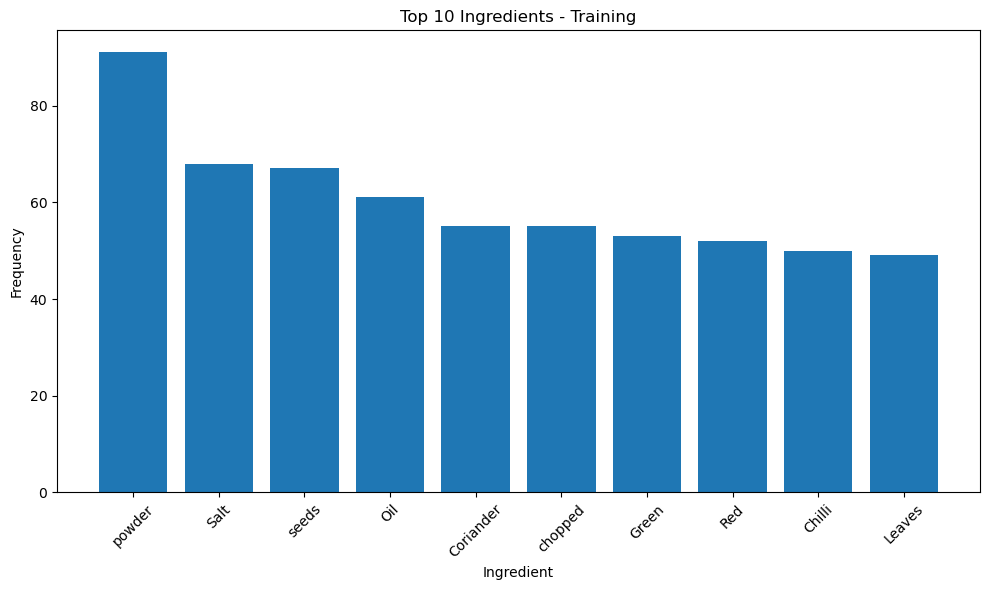

In [438]:
# plot the top frequent ingredients in training data
plot_top_items(ingredients, 'ingredient', 'Training', top_n=10)

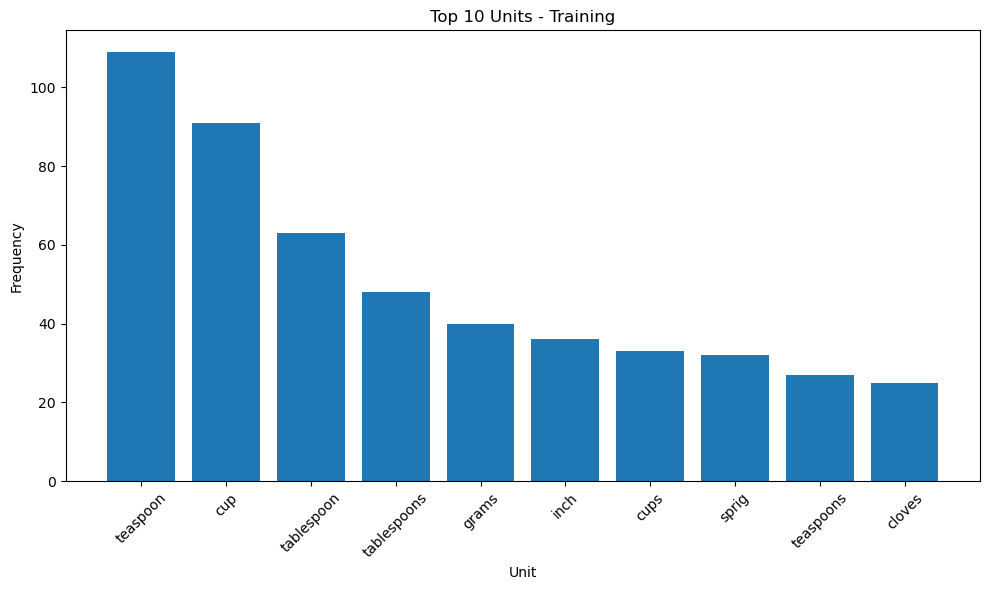

In [439]:
# plot the top frequent units in training data
plot_top_items(units, 'unit', 'Training', top_n=10)


## **5** Exploratory Recipe Data Analysis on Validation Dataset (Optional)<font color = red> [0 marks]</font> <br>

#### **5.1** *Execute EDA on Validation Dataset with insights (Optional)* <font color = red> [0 marks]</font> <br>
Initialise the dataset_name as ***Validation*** and call the ***plot_top_items*** for top 10 ingredients and units in the recipe data
Provide the insights for the same.



In [440]:
# initialise the dataset_name


In [441]:
# use extract and validate tokens, categorise tokens, get top frequent items for ingredient list and unit list on validation dataframe


In [442]:
# plot the top frequent ingredients in validation data


In [443]:
# plot the top frequent units in training data


## **6** Feature Extraction For CRF Model <font color = red>[30 marks]</font> <br>

### **6.1** *Define a feature functions to take each token from recipe* <font color = red>[10 marks]</font>

Define a function as ***word2features*** which takes a particular recipe and its index to work with all recipe input tokens and include custom key-value pairs.

Also, use feature key-value pairs to mark the beginning and end of the sequence and to also check whether the word belongs to unit, quantity etc. Use keyword sets for unit and quantity for differentiating feature functions well. Also make use of relevant regex patterns on fractions, whole numbers etc.

##### **6.1.1** **Define keywords for unit and quantity and create a quantity pattern to work on fractions, numbers and decimals** <font color = red>[3 marks]</font> <br>

Create sets for **unit_keywords** and ***quantity_keywords*** and include all the words relevant for measuring the ingredients such as cup, tbsp, tsp etc. and in quantity keywords, include words such as half, quarter etc.

Also suggested to use regex pattern as ***quantity_pattern*** to work with quantity in any format such as fractions, numbers and decimals.

Then, load the spacy model and process the entire sentence

In [444]:
# define unit and quantity keywords along with quantity pattern
 
# Unit Keywords - Comprehensive set of measurement units
unit_keywords = {
# Volume measurements
'cup', 'cups', 'c', 'c.','tablespoon', 'tablespoons', 'tbsp', 'tbsp.', 'tbs', 'tbs.','teaspoon', 'teaspoons', 'tsp', 'tsp.', 'ts', 'ts.','fluid ounce', 'fluid ounces', 'fl oz', 'fl. oz.', 'floz','pint', 'pints', 'pt', 'pt.','quart', 'quarts', 'qt', 'qt.','gallon', 'gallons', 'gal', 'gal.','liter', 'liters', 'litre', 'litres', 'l', 'l.',
'milliliter', 'milliliters', 'millilitre', 'millilitres', 'ml', 'ml.',

# Weight measurements
'pound', 'pounds', 'lb', 'lbs', 'lb.', 'lbs.','ounce', 'ounces', 'oz', 'oz.','gram', 'grams', 'g', 'g.','kilogram', 'kilograms', 'kg', 'kg.','milligram', 'milligrams', 'mg', 'mg.','ton', 'tons',

# Length measurements (for baking)
'inch', 'inches', 'in', 'in.',
'foot', 'feet', 'ft', 'ft.',
'centimeter', 'centimeters', 'cm', 'cm.',
'millimeter', 'millimeters', 'mm', 'mm.',

# Temperature
'degree', 'degrees', 'fahrenheit', 'celsius', 'f', 'c',

# Count-based units
'piece', 'pieces', 'pc', 'pcs','slice', 'slices','clove', 'cloves','head', 'heads','bunch', 'bunches','sprig', 'sprigs','stalk', 'stalks','leaf', 'leaves','strip', 'strips','wedge', 'wedges','segment', 'segments',

# Container-based units
'can', 'cans','jar', 'jars','bottle', 'bottles','box', 'boxes','bag', 'bags','package', 'packages', 'pkg', 'pkgs','container', 'containers','tube', 'tubes','packet', 'packets','pouch', 'pouches',

# Cooking-specific units
'pinch', 'pinches','dash', 'dashes','splash', 'splashes','handful', 'handfuls','drop', 'drops','squeeze','dollop', 'dollops','knob', 'knobs','pat', 'pats','stick', 'sticks','cube', 'cubes','block', 'blocks','sheet', 'sheets','layer', 'layers',

# Generic units
'unit', 'units',
'serving', 'servings',
'portion', 'portions',
'part', 'parts'
}

# Quantity Keywords - Words indicating amounts
quantity_keywords = {
# Fractional quantities
'half', 'halves',
'quarter', 'quarters',
'third', 'thirds','eighth', 'eighths','sixteenth', 'sixteenths',

# Descriptive quantities
'few', 'several', 'some', 'many', 'lots', 'plenty',
'little', 'bit', 'touch', 'hint', 'trace','small', 'medium', 'large', 'extra large','tiny', 'huge', 'enormous',

# Multipliers
'single', 'double', 'triple', 'quadruple','twice', 'thrice',

# Approximations
'about', 'approximately', 'around', 'roughly','nearly', 'almost', 'just over', 'just under','up to', 'at least', 'no more than',

# Ranges
'to', 'or', 'between', 'and',

# Portions
'whole', 'entire', 'complete','partial', 'remaining', 'rest',

# Cooking-specific quantities
'generous', 'scant', 'heaping', 'level','packed', 'unpacked', 'loose','fresh', 'dried', 'frozen','cooked', 'uncooked', 'raw',

# Comparative quantities
'more', 'less', 'extra', 'additional','enough', 'sufficient', 'adequate'
}

# Combined comprehensive pattern
quantity_pattern = r'''
(?:
# Unicode fractions
[½¼¾⅐⅑⅒⅓⅔⅕⅖⅗⅘⅙⅚⅛⅜⅝⅞]+
|
# Mixed numbers with dash (1-1/2)
\d+-\d+/\d+
|
# Mixed numbers with space (1 1/2)
\d+\s+\d+/\d+
|
# Simple fractions (1/2)
\d+/\d+
|
# Decimal ranges (1.5-2.0)
\d+\.\d+\s*-\s*\d+\.\d+
|
# Number ranges with dash (1-2)
\d+\s*-\s*\d+
|
# Number ranges with "to" (1 to 2)
\d+\s+to\s+\d+
|
# Decimal numbers (1.5)
\d+\.\d+
|
# Whole numbers (1, 2, 3)
\d+
|
# Approximations (about 2, ~3)
(?:about|approximately|around|roughly|~)\s*\d+(?:\.\d+)?
|
# Numbers with plus (2+)
\d+(?:\.\d+)?\+
|
# Parenthetical numbers ((2))
\(\d+(?:\.\d+)?(?:-\d+(?:\.\d+)?)?\)
)
'''

# Compile the main pattern
compiled_quantity_pattern = re.compile(quantity_pattern, re.VERBOSE | re.IGNORECASE)


In [445]:
# load spaCy model


##### **6.1.2** **Define feature functions for CRF** <font color = red>[7 marks]</font> <br>

Define ***word2features*** function and use the parameters such as sentence and its indexing as ***sent*** and ***i*** for extracting token level features for CRF Training.
Build ***features*** dictionary, also mark the beginning and end of the sequence and use the ***unit_keywords***, ***quantity_keywords*** and ***quantity_pattern*** for knowing the presence of quantity or unit in the tokens

While building ***features*** dictionary, include
- ***Core Features*** - The core features of a token should capture its lexical
and grammatical properties. Include attributes like the raw token, its lemma, part-of-speech tag, dependency relation, and shape, as well as indicators for whether it's a stop word, digit, or punctuation. The details of the features are given below:

    - `bias` - Constant feature with a fixed value of 1.0 to aid model learning.
    - `token` - The lowercase form of the current token.
    - `lemma` - The lowercase lemma (base form) of the token.
    - `pos_tag` - Part-of-speech (POS) tag of the token.
    - `tag` - Detailed POS tag of the token.
    - `dep` - Dependency relation of the token in the sentence.
    - `shape` - Shape of the token (e.g., "Xxx" for "Milk").
    - `is_stop` - Boolean indicating if the token is a stopword.
    - `is_digit` - Boolean indicating if the token consists of only digits.
    - `has_digit` - Boolean indicating if the token contains at least one digit.
    - `has_alpha` - Boolean indicating if the token contains at least one alphabetic character.
    - `hyphenated` - Boolean indicating if the token contains a hyphen (-).
    - `slash_present` - Boolean indicating if the token contains a slash (/).
    - `is_title` - Boolean indicating if the token starts with an uppercase letter.
    - `is_upper` - Boolean indicating if the token is fully uppercase.
    - `is_punct` - Boolean indicating if the token is a punctuation mark.

- ***Improved Quantity and Unit Detection*** - Use key-value pairs to mark the presence of quantities and units in the features dictionary. Utilise the unit_keywords, quantity_keywords, and quantity_pattern to identify and flag these elements. The details of the features are given below:

    - `is_quantity` - Boolean indicating if the token matches a quantity pattern or keyword.
    - `is_unit` - Boolean indicating if the token is a known measurement unit.
    - `is_numeric` - Boolean indicating if the token matches a numeric pattern.
    - `is_fraction` - Boolean indicating if the token represents a fraction (e.g., 1/2).
    - `is_decimal` - Boolean indicating if the token represents a decimal number (e.g., 3.14).
    - `preceding_word` - The previous token in the sentence, if available.
    - `following_word` - The next token in the sentence, if available.

- ***Contextual Features*** - Incorporate contextual information by adding features for the preceding and following tokens. Include indicators like BOS and EOS to mark the beginning and end of the sequence, and utilise unit_keywords, quantity_keywords, and quantity_pattern to identify the types of neighboring tokens. The features are given below:

    - `prev_token` - The lowercase form of the previous token.
    - `prev_is_quantity` - Boolean indicating if the previous token is a quantity.
    - `prev_is_digit` - Boolean indicating if the previous token is a digit.
    - `BOS` - Boolean indicating if the token is at the beginning of the sentence.
    - `next_token` - The lowercase form of the next token.
    - `next_is_unit` - Boolean indicating if the next token is a unit.
    - `next_is_ingredient` - Boolean indicating if the next token is not a unit or quantity.
    - `EOS` - Boolean indicating if the token is at the end of the sentence.



In [446]:
# define word2features for processing each token in the sentence sent by using index i.
# use your own feature functions

import re
from fractions import Fraction

def word2features(recipe_tokens, i):
    # Get the current word
    word = recipe_tokens[i]
    
    # Define keyword sets for units and quantities
    unit_keywords = {
        'cup', 'cups', 'tablespoon', 'tablespoons', 'tbsp', 'teaspoon', 'teaspoons', 'tsp',
        'ounce', 'ounces', 'oz', 'pound', 'pounds', 'lb', 'lbs', 'gram', 'grams', 'g',
        'kilogram', 'kg', 'liter', 'liters', 'l', 'milliliter', 'ml', 'pint', 'pints',
        'quart', 'quarts', 'gallon', 'gallons', 'inch', 'inches', 'clove', 'cloves',
        'piece', 'pieces', 'slice', 'slices', 'bunch', 'bunches', 'sprig', 'sprigs',
        'pinch', 'dash', 'handful', 'can', 'cans', 'bottle', 'bottles', 'jar', 'jars',
        'packet', 'packets', 'box', 'boxes', 'bag', 'bags', 'unit', 'units'
    }
    
    quantity_keywords = {
        'few', 'some', 'little', 'bit', 'lots', 'many', 'several', 'enough',
        'plenty', 'half', 'quarter', 'third', 'double', 'triple'
    }
    
    # Initialize features dictionary
    features = {
        # Basic word features
        'word.lower()': word.lower(),
        'word.isupper()': word.isupper(),
        'word.istitle()': word.istitle(),
        'word.isdigit()': word.isdigit(),
        'word.isalpha()': word.isalpha(),
        'word.isalnum()': word.isalnum(),
        'word.length': len(word),
        
        # Position features - Beginning and End of Sequence (BOS/EOS)
        'BOS': i == 0,  # Beginning of sequence
        'EOS': i == len(recipe_tokens) - 1,  # End of sequence
        'position': i,
        'relative_position': i / len(recipe_tokens) if len(recipe_tokens) > 0 else 0,
        
        # Word shape features
        'word.shape': get_word_shape(word),
        'word.prefix-2': word[:2] if len(word) >= 2 else word,
        'word.prefix-3': word[:3] if len(word) >= 3 else word,
        'word.suffix-2': word[-2:] if len(word) >= 2 else word,
        'word.suffix-3': word[-3:] if len(word) >= 3 else word,
        
        # Keyword membership features
        'is_unit_keyword': word.lower() in unit_keywords,
        'is_quantity_keyword': word.lower() in quantity_keywords,
        
        # Numeric and fraction patterns
        'is_number': bool(re.match(r'^\d+$', word)),
        'is_decimal': bool(re.match(r'^\d+\.\d+$', word)),
        'is_fraction': bool(re.match(r'^\d+/\d+$', word)),
        'is_mixed_number': bool(re.match(r'^\d+-\d+/\d+$', word)),
        'contains_number': bool(re.search(r'\d', word)),
        'is_range': bool(re.match(r'^\d+-\d+$', word)),
        
        # Special character patterns
        'has_hyphen': '-' in word,
        'has_slash': '/' in word,
        'has_dot': '.' in word,
        'has_comma': ',' in word,
        
        # Capitalization patterns
        'is_capitalized': word[0].isupper() if word else False,
        'is_all_caps': word.isupper(),
        'is_mixed_case': any(c.isupper() for c in word) and any(c.islower() for c in word),
    }
    
    # Context features - Previous word (if exists)
    if i > 0:
        prev_word = recipe_tokens[i-1]
        features.update({
            'prev_word.lower()': prev_word.lower(),
            'prev_word.istitle()': prev_word.istitle(),
            'prev_word.isupper()': prev_word.isupper(),
            'prev_word.isdigit()': prev_word.isdigit(),
            'prev_word.is_unit': prev_word.lower() in unit_keywords,
            'prev_word.is_quantity': prev_word.lower() in quantity_keywords,
            'prev_word.shape': get_word_shape(prev_word),
        })
    else:
        # Features for beginning of sequence
        features.update({
            'prev_word.lower()': '<BOS>',
            'prev_word.istitle()': False,
            'prev_word.isupper()': False,
            'prev_word.isdigit()': False,
            'prev_word.is_unit': False,
            'prev_word.is_quantity': False,
            'prev_word.shape': '<BOS>',
        })
    
    # Context features - Next word (if exists)
    if i < len(recipe_tokens) - 1:
        next_word = recipe_tokens[i+1]
        features.update({
            'next_word.lower()': next_word.lower(),
            'next_word.istitle()': next_word.istitle(),
            'next_word.isupper()': next_word.isupper(),
            'next_word.isdigit()': next_word.isdigit(),
            'next_word.is_unit': next_word.lower() in unit_keywords,
            'next_word.is_quantity': next_word.lower() in quantity_keywords,
            'next_word.shape': get_word_shape(next_word),
        })
    else:
        # Features for end of sequence
        features.update({
            'next_word.lower()': '<EOS>',
            'next_word.istitle()': False,
            'next_word.isupper()': False,
            'next_word.isdigit()': False,
            'next_word.is_unit': False,
            'next_word.is_quantity': False,
            'next_word.shape': '<EOS>',
        })
    
    # Bigram features
    if i > 0:
        features['prev_word+word'] = f"{recipe_tokens[i-1].lower()}+{word.lower()}"
    if i < len(recipe_tokens) - 1:
        features['word+next_word'] = f"{word.lower()}+{recipe_tokens[i+1].lower()}"
    
    # Advanced numeric features
    if word.isdigit() or re.match(r'^\d+/\d+$', word) or re.match(r'^\d+-\d+/\d+$', word):
        features.update({
            'numeric_value': extract_numeric_value(word),
            'is_small_number': is_small_number(word),
            'is_large_number': is_large_number(word),
        })
    
    return features

def get_word_shape(word):
    """
    Get the shape of a word (pattern of characters)
    """
    if not word:
        return ''
    
    shape = ''
    for char in word:
        if char.isupper():
            shape += 'X'
        elif char.islower():
            shape += 'x'
        elif char.isdigit():
            shape += 'd'
        else:
            shape += char
    
    # Compress consecutive same characters
    compressed = ''
    prev_char = ''
    for char in shape:
        if char != prev_char:
            compressed += char
            prev_char = char
    
    return compressed

def extract_numeric_value(word):
    """
    Extract numeric value from various formats
    """
    try:
        # Simple integer
        if word.isdigit():
            return float(word)
        
        # Fraction
        if re.match(r'^\d+/\d+$', word):
            return float(Fraction(word))
        
        # Mixed number (e.g., "2-1/2")
        if re.match(r'^\d+-\d+/\d+$', word):
            parts = word.split('-')
            whole = int(parts[0])
            fraction = float(Fraction(parts[1]))
            return whole + fraction
        
        # Decimal
        if re.match(r'^\d+\.\d+$', word):
            return float(word)
        
        return 0.0
    except:
        return 0.0

def is_small_number(word):
    """
    Check if the number is considered small (< 10)
    """
    value = extract_numeric_value(word)
    return 0 < value < 10

def is_large_number(word):
    """
    Check if the number is considered large (>= 100)
    """
    value = extract_numeric_value(word)
    return value >= 100



# Function to extract features for multiple recipes
def extract_features_batch(token_sequences):
    """
    Extract features for multiple recipes
    """
    return [recipe2features(tokens) for tokens in token_sequences]

    # Process the entire sentence with spaCy

    # --- Core Features ---

    # --- Improved Quantity & Unit Detection ---

    # --- Contextual Features ---


### **6.2** *Preparation of Recipe level features* <font color = red>[2 marks]</font>


##### **6.2.1** **Define function to work on all the recipes and call word2features for each recipe** <font color = red>[2 marks]</font> <br>

Define ***sent2features*** function and inputs ***sent*** as a parameter and correctly generate feature functions for each token present in the sentence

In [447]:
# define sent2features by working on each token in the sentence and correctly generate dictionaries for features
# Function to extract features for entire recipe
def sent2features(recipe_tokens):
    return [word2features(recipe_tokens, i) for i in range(len(recipe_tokens))]



### **6.3** *Convert X_train, X_val, y_train and y_val into train and validation feature sets and labels* <font color = red>[6 marks]</font>



##### **6.3.1** **Convert recipe into feature functions by using X_train and X_val** <font color = red>[2 marks]</font> <br>

Create ***X_train_features*** and ***X_val_features*** as list to include the feature functions for each recipe present in training and validation sets

In [448]:
# Convert input sentences into feature sets by taking training and validation dataset as X_train_features and X_val_features
def create_feature_sets(X_train_tokens, X_val_tokens):
    
    print("Creating feature sets for CRF model...")
    
    # Training features
    print("\n1. Processing Training Data:")
    print("-" * 40)
    X_train_features = []
    
    for i, recipe_tokens in enumerate(X_train_tokens):
        if recipe_tokens:  # Skip empty recipes
            recipe_features = [word2features(recipe_tokens, j) for j in range(len(recipe_tokens))]
            X_train_features.append(recipe_features)
        else:
            X_train_features.append([])  # Empty recipe
        
        if (i + 1) % 25 == 0:
            print(f"  Processed {i + 1}/{len(X_train_tokens)} training recipes")
    
    # Validation features
    print("\n2. Processing Validation Data:")
    print("-" * 40)
    X_val_features = []
    
    for i, recipe_tokens in enumerate(X_val_tokens):
        if recipe_tokens:  # Skip empty recipes
            recipe_features = [word2features(recipe_tokens, j) for j in range(len(recipe_tokens))]
            X_val_features.append(recipe_features)
        else:
            X_val_features.append([])  # Empty recipe
        
        if (i + 1) % 25 == 0:
            print(f"  Processed {i + 1}/{len(X_val_tokens)} validation recipes")
    
    # Summary
    print("\n" + "=" * 50)
    print("FEATURE EXTRACTION SUMMARY")
    print("=" * 50)
    print(f"Training recipes: {len(X_train_features)}")
    print(f"Validation recipes: {len(X_val_features)}")
    
    if X_train_features and X_train_features[0]:
        print(f"Sample training recipe length: {len(X_train_features[0])} words")
        print(f"Features per word: {len(X_train_features[0][0])} features")
    
    return X_train_features, X_val_features

# Execute feature creation
X_train_features, X_val_features = create_feature_sets(X_train, X_val)

Creating feature sets for CRF model...

1. Processing Training Data:
----------------------------------------
  Processed 25/142 training recipes
  Processed 50/142 training recipes
  Processed 75/142 training recipes
  Processed 100/142 training recipes
  Processed 125/142 training recipes

2. Processing Validation Data:
----------------------------------------
  Processed 25/62 validation recipes
  Processed 50/62 validation recipes

FEATURE EXTRACTION SUMMARY
Training recipes: 142
Validation recipes: 62
Sample training recipe length: 41 words
Features per word: 49 features


##### **6.3.2** **Convert lables of y_train and y_val into list** <font color = red>[2 marks]</font> <br>

Create ***y_train_labels*** and ***y_val_labels*** by using the list of y_train and y_val

In [449]:
# Convert labels into list as y_train_labels and y_val_labels
y_train_labels = list(y_train)
y_val_labels = list(y_val)

print("Label conversion completed:")
print(f"y_train_labels: {len(y_train_labels)} sequences")
print(f"y_val_labels: {len(y_val_labels)} sequences")

# Display sample
if y_train_labels:
    print(f"Sample y_train_labels[0]: {y_train_labels[0][:10]}...")
if y_val_labels:
    print(f"Sample y_val_labels[0]: {y_val_labels[0][:10]}...")

Label conversion completed:
y_train_labels: 142 sequences
y_val_labels: 62 sequences
Sample y_train_labels[0]: ['quantity', 'unit', 'ingredient', 'ingredient', 'ingredient', 'quantity', 'unit', 'ingredient', 'ingredient', 'ingredient']...
Sample y_val_labels[0]: ['quantity', 'unit', 'ingredient', 'quantity', 'unit', 'ingredient', 'quantity', 'ingredient', 'ingredient', 'unit']...


##### **6.3.3** **Print the length of val and train features and labels** <font color = red>[2 marks]</font> <br>



In [450]:
# print the length of train features and labels
print(len(X_train_features), len(y_train_labels))


142 142


In [451]:
# print the length of validation features and labels
print(len(X_val_features), len(y_val_labels))


62 62


### **6.4** *Applying weights to feature sets* <font color = red>[12 marks]</font> <br>




##### **6.4.1** **Flatten the labels of y_train** <font color = red>[2 marks]</font> <br>

Create ***y_train_flat*** to flatten the structure of nested y_train

In [452]:
# Flatten labels in y_train
y_train_flat = [label for sequence in y_train for label in sequence]
print(f"✅ y_train_flat created: {len(y_train_flat)} labels")
print(f"Sample: {y_train_flat[:15]}")


✅ y_train_flat created: 4632 labels
Sample: ['quantity', 'unit', 'ingredient', 'ingredient', 'ingredient', 'quantity', 'unit', 'ingredient', 'ingredient', 'ingredient', 'quantity', 'ingredient', 'ingredient', 'ingredient', 'quantity']


##### **6.4.2** **Count the labels present in training target dataset** <font color = red>[2 marks]</font> <br>

Create ***label_counts*** to count the frequencies of labels present in y_train_flat and retrieve the total samples by using the values of label_counts as ***total_samples***

In [453]:
# Count label frequencies as label_counts and total_samples as getting the summation of values of label_counts

label_counts = Counter(y_train_flat)
total_samples = sum(label_counts.values())

print(f"label_counts: {dict(label_counts)}")
print(f"total_samples: {total_samples}")

# Verify
print(f"Verification: {len(y_train_flat)} == {total_samples} ? {len(y_train_flat) == total_samples}")


label_counts: {'quantity': 658, 'unit': 563, 'ingredient': 3411}
total_samples: 4632
Verification: 4632 == 4632 ? True


##### **6.4.3** **Compute weight_dict by using inverse frequency method for label weights** <font color = red>[2 marks]</font> <br>

- Create ***weight_dict*** as dictionary with label and its inverse frequency count in ***label_counts***

- Penalise ingredient label in the dictionary

In [454]:
# Compute class weights (inverse frequency method) by considering total_samples and label_counts
ingredient_penalty = 2.0
print("Creating weight dictionary...")
print(f"Total samples: {total_samples}")
print(f"Ingredient penalty factor: {ingredient_penalty}")


    
print(f"\nCalculating weights:")
print("-" * 40)

for label, count in label_counts.items():
    weight_dict = {}
    # Calculate inverse frequency weight
    inverse_freq_weight = total_samples / count
    
    # Apply penalty to ingredient label
    if label.lower() == 'ingredient':
        final_weight = inverse_freq_weight * ingredient_penalty
        print(f"{label:<12}: count={count:<6} -> inv_freq={inverse_freq_weight:.3f} -> penalized={final_weight:.3f}")
    else:
        final_weight = inverse_freq_weight
        print(f"{label:<12}: count={count:<6} -> weight={final_weight:.3f}")
    
    weight_dict[label] = final_weight

weight_dict


Creating weight dictionary...
Total samples: 4632
Ingredient penalty factor: 2.0

Calculating weights:
----------------------------------------
quantity    : count=658    -> weight=7.040
unit        : count=563    -> weight=8.227
ingredient  : count=3411   -> inv_freq=1.358 -> penalized=2.716


{'ingredient': 2.7159190853122253}

In [455]:
# penalise ingredient label
for label, weight in weight_dict.items():
    count = label_counts[label]
    penalty_info = " (PENALIZED)" if label.lower() == 'ingredient' else ""
    print(f"{label}: {weight:.3f}{penalty_info} (original count: {count})")

print(f"\nweight_dict = {weight_dict}")


ingredient: 2.716 (PENALIZED) (original count: 3411)

weight_dict = {'ingredient': 2.7159190853122253}


##### **6.4.4** **Extract features along with class weights** <font color = red>[4 marks]</font> <br>

Define a function ***extract_features_with_class_weights*** to work with training and validation datasets and extract features by applying class weights





In [456]:
# Apply weights to feature extraction in extract_features_with_class_weights by using parameters such as X (input tokens), y(labels) and weight_dict (Class weights)
def extract_features_with_class_weights(X, y, weight_dict, dataset_name="Dataset"):
    
    print(f"Extracting features with class weights for {dataset_name}...")
    print(f"Number of sequences: {len(X)}")
    print(f"Weight dictionary: {weight_dict}")
    
    weighted_features = []
    processed_labels = []
    sample_weights = []
    
    for seq_idx, (tokens, labels) in enumerate(zip(X, y)):
        if len(tokens) != len(labels):
            print(f"Warning: Length mismatch in sequence {seq_idx}: tokens={len(tokens)}, labels={len(labels)}")
            continue
        
        # Extract base features for this sequence
        sequence_features = []
        sequence_labels = []
        sequence_weights = []
        
        for word_idx in range(len(tokens)):
            # Extract word features
            word_features = word2features(tokens, word_idx)
            
            # Get corresponding label 
            label = labels[word_idx]
            
            # Get class weight for this label
            class_weight = weight_dict.get(label, 1.0)
            
            # Add class weight as a feature
            word_features['class_weight'] = class_weight
            word_features['weighted_importance'] = class_weight
            
            # Store results
            sequence_features.append(word_features)
            sequence_labels.append(label)
            sequence_weights.append(class_weight)
        
        weighted_features.append(sequence_features)
        processed_labels.append(sequence_labels)
        sample_weights.append(sequence_weights)
        
        # Progress indicator
        if (seq_idx + 1) % 50 == 0:
            print(f"  Processed {seq_idx + 1}/{len(X)} sequences...")
    
    print(f"\nFeature extraction with weights complete for {dataset_name}:")
    print(f"  Processed sequences: {len(weighted_features)}")
    print(f"  Total words: {sum(len(seq) for seq in weighted_features)}")
    
    # Calculate weight statistics
    all_weights = [w for seq_weights in sample_weights for w in seq_weights]
    if all_weights:
        print(f"  Weight statistics:")
        print(f"    Min weight: {min(all_weights):.3f}")
        print(f"    Max weight: {max(all_weights):.3f}")
        print(f"    Avg weight: {sum(all_weights)/len(all_weights):.3f}")
    
    return weighted_features, processed_labels, sample_weights



##### **6.4.5** **Execute extract_features_with_class_weights on training and validation datasets** <font color = red>[2 marks]</font> <br>

Create ***X_train_weighted_features*** and ***X_val_weighted_features*** for extracting training and validation features along with their weights by calling ***extract_features_with_class_weights*** on the datasets

In [457]:
# Apply manually computed class weights
# Check dimensions

# Apply to training data
print("-" * 40)
print("EXTRACTING WEIGHTED FEATURES FOR TRAINING DATA")
print("-" * 40)

X_train_weighted_features, y_train_weighted_labels, train_sample_weights = extract_features_with_class_weights(
    X_train, y_train, weight_dict, "Training"
)

# Apply to validation data
print("\n" + "=" * 60)
print("EXTRACTING WEIGHTED FEATURES FOR VALIDATION DATA")
print("=" * 60)

X_val_weighted_features, y_val_weighted_labels, val_sample_weights = extract_features_with_class_weights(
    X_val, y_val, weight_dict, "Validation"
)


----------------------------------------
EXTRACTING WEIGHTED FEATURES FOR TRAINING DATA
----------------------------------------
Extracting features with class weights for Training...
Number of sequences: 142
Weight dictionary: {'ingredient': 2.7159190853122253}
  Processed 50/142 sequences...
  Processed 100/142 sequences...

Feature extraction with weights complete for Training:
  Processed sequences: 142
  Total words: 4632
  Weight statistics:
    Min weight: 1.000
    Max weight: 2.716
    Avg weight: 2.264

EXTRACTING WEIGHTED FEATURES FOR VALIDATION DATA
Extracting features with class weights for Validation...
Number of sequences: 62
Weight dictionary: {'ingredient': 2.7159190853122253}
  Processed 50/62 sequences...

Feature extraction with weights complete for Validation:
  Processed sequences: 62
  Total words: 2149
  Weight statistics:
    Min weight: 1.000
    Max weight: 2.716
    Avg weight: 2.286


## **7** Model Building and Training <font color = red>[10 marks]</font> <br>

### **7.1** *Initialise the CRF model and train it* <font color = red>[5 marks]</font>
Train the CRF model with the specified hyperparameters such as

### CRF Model Hyperparameters Explanation

| Parameter                  | Description |
|----------------------------|-------------|
| **algorithm='lbfgs'**      | Optimisation algorithm used for training. `lbfgs` (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) is a quasi-Newton optimisation method. |
| **c1=0.5**                | L1 regularisation term to control sparsity in feature weights. Helps in feature selection. |
| **c2=1.0**                | L2 regularisation term to prevent overfitting by penalising large weights. |
| **max_iterations=100**     | Maximum number of iterations for model training. Higher values allow more convergence but increase computation time. |
| **all_possible_transitions=True** | Ensures that all possible state transitions are considered in training, making the model more robust. |

Use weight_dict for training CRF



In [458]:
# initialise CRF model with the specified hyperparameters and use weight_dict
from sklearn_crfsuite import CRF

crf_weighted = CRF(
    algorithm='lbfgs',
    c1=0.5,
    c2=1.0,
    max_iterations=100,
    all_possible_transitions=True
)
# train the CRF model with the weighted training data
print("Training CRF with weighted features...")
crf_weighted.fit(X_train_weighted_features, y_train_weighted_labels)

Training CRF with weighted features...


CRF(algorithm='lbfgs', all_possible_transitions=True, c1=0.5, c2=1.0,
    max_iterations=100)

### **7.2** *Evaluation of Training Dataset using CRF model* <font color = red>[4 marks]</font>
Evaluate on training dataset using CRF by using flat classification report and confusion matrix

In [459]:
# evaluate on the training dataset
y_pred_weighted = crf_weighted.predict(X_val_weighted_features)

In [460]:
# specify the flat classification report by using training data for evaluation

print("CRF MODEL EVALUATION - TRAINING DATA")
print("=" * 50)

# Make predictions on training data
y_train_pred = crf_weighted.predict(X_train_weighted_features)

# Generate flat classification report for training data
train_classification_report = flat_classification_report(
    y_train_labels, 
    y_train_pred,
    labels=['ingredient', 'unit', 'quantity'],
    digits=4
)

print("Training Data Classification Report:")
print(train_classification_report)



CRF MODEL EVALUATION - TRAINING DATA
Training Data Classification Report:
              precision    recall  f1-score   support

  ingredient     0.9924    1.0000    0.9962      3411
        unit     0.9946    0.9787    0.9866       563
    quantity     1.0000    0.9742    0.9869       658

    accuracy                         0.9937      4632
   macro avg     0.9957    0.9843    0.9899      4632
weighted avg     0.9938    0.9937    0.9937      4632



In [461]:
# create a confusion matrix on training datset

from sklearn_crfsuite import metrics

train_accuracy = metrics.flat_accuracy_score(y_train_labels, y_train_pred)
train_f1_weighted = metrics.flat_f1_score(y_train_labels, y_train_pred, average='weighted')
train_f1_macro = metrics.flat_f1_score(y_train_labels, y_train_pred, average='macro')

print(f"\nTraining Metrics Summary:")
print(f"Accuracy:        {train_accuracy:.4f}")
print(f"F1-Score (weighted): {train_f1_weighted:.4f}")
print(f"F1-Score (macro):    {train_f1_macro:.4f}")


Training Metrics Summary:
Accuracy:        0.9937
F1-Score (weighted): 0.9937
F1-Score (macro):    0.9899


### **7.3** *Save the CRF model* <font color = red>[1 marks]</font>
Save the CRF model

In [462]:
# dump the model using joblib as crf_model.pkl

import joblib

print("Saving CRF model...")

# Save the model
joblib.dump(crf_weighted, 'crf_model.pkl')

print("✅ CRF model saved as 'crf_model.pkl'")

# Verify the save
import os
if os.path.exists('crf_model.pkl'):
    file_size = os.path.getsize('crf_model.pkl')
    print(f"File size: {file_size:,} bytes")
    print(f"Full path: {os.path.abspath('crf_model.pkl')}")

Saving CRF model...
✅ CRF model saved as 'crf_model.pkl'
File size: 185,484 bytes
Full path: /Users/kandarp.joshi/Library/CloudStorage/OneDrive-ServiceNow/Prd/Prd/UpGrad/C5/M2/Assignment/Starter Notebook Data/crf_model.pkl


## **8** Prediction and Model Evaluation <font color = red>[3 marks]</font> <br>

### **8.1** *Predict and Evaluate the CRF model on validation set* <font color = red>[3 marks]</font>
Evaluate the metrics for CRF model by using flat classification report and confusion matrix




In [463]:
# predict the crf model on validation dataset
y_val_pred = crf_weighted.predict(X_val_weighted_features)

In [464]:
# specify flat classification report
print("\nValidation Performance:")
print(flat_classification_report(y_val_labels, y_val_pred, digits=4))

# Store predictions for further analysis
validation_predictions = y_val_pred



Validation Performance:
              precision    recall  f1-score   support

  ingredient     0.9951    1.0000    0.9975      1611
    quantity     1.0000    0.9694    0.9845       294
        unit     0.9918    0.9959    0.9939       244

    accuracy                         0.9953      2149
   macro avg     0.9956    0.9884    0.9919      2149
weighted avg     0.9954    0.9953    0.9953      2149



In [465]:
# create a confusion matrix on validation dataset

#from sklearn.metrics import confusion_matrix
#import matplotlib.pyplot as plt
#import seaborn as sns

# Flatten the predictions and true labels
y_val_true_flat = [label for seq in y_val_labels for label in seq]
y_val_pred_flat = [label for seq in y_val_pred for label in seq]

# Create confusion matrix
labels = ['ingredient', 'unit', 'quantity']
cm = confusion_matrix(y_val_true_flat, y_val_pred_flat, labels=labels)

print("Validation Confusion Matrix:")
print(cm)


Validation Confusion Matrix:
[[1611    0    0]
 [   1  243    0]
 [   7    2  285]]


## **9** Error Analysis on Validation Data <font color = red>[10 marks]</font> <br>
Investigate misclassified samples in validation dataset and provide the insights


### **9.1** *Investigate misclassified samples in validation dataset* <font color = red>[8 marks]</font>



##### **9.1.1** Flatten the labels of validation data and initialise error data <font color = red>[2 marks]</font> <br>



Flatten the true and predicted labels and initialise the error data as ***error_data***

In [466]:

# Simple flattening and error data initialization
print("FLATTENING LABELS AND INITIALIZING ERROR DATA")
print("=" * 40)

# Flatten true labels
y_true_flat = [label for sequence in y_val_labels for label in sequence]

# Flatten predicted labels  
y_pred_flat = [label for sequence in y_val_pred for label in sequence]

# Initialize error data
error_data = []

for i, (true_label, pred_label) in enumerate(zip(y_true_flat, y_pred_flat)):
    if true_label != pred_label:
        error_data.append({
            'index': i,
            'true_label': true_label,
            'predicted_label': pred_label
        })



FLATTENING LABELS AND INITIALIZING ERROR DATA


##### **9.1.2** Iterate the validation data and collect Error Information<font color = red> [2 marks]</font> <br>



Iterate through validation data (X_val, y_val_labels, y_pred_val) and compare true vs. predicted labels. Collect error details, including surrounding context, previous/next tokens, and class weights, then store them in error_data

In [467]:
# iterate and collect Error Information
def collect_comprehensive_error_details(X_val, y_val_labels, y_pred_val):
    
    print("COLLECTING COMPREHENSIVE ERROR DETAILS")
    print("=" * 50)
    
    error_details = []
    total_tokens = 0
    total_errors = 0
    
    # Iterate through each sequence
    for seq_idx, (tokens, true_labels, pred_labels) in enumerate(zip(X_val, y_val_labels, y_pred_val)):
        
        # Ensure all sequences have same length
        min_length = min(len(tokens), len(true_labels), len(pred_labels))
        
        if len(tokens) != len(true_labels) or len(tokens) != len(pred_labels):
            print(f"Warning: Length mismatch in sequence {seq_idx}")
            print(f"  Tokens: {len(tokens)}, True: {len(true_labels)}, Pred: {len(pred_labels)}")
        
        # Iterate through each token in the sequence
        for token_idx in range(min_length):
            total_tokens += 1
            
            true_label = true_labels[token_idx]
            pred_label = pred_labels[token_idx]
            current_token = tokens[token_idx]
            
            # Check if this is an error
            if true_label != pred_label:
                total_errors += 1
                
                # Collect comprehensive error details
                error_detail = {
                    # Basic identification
                    'error_id': len(error_details),
                    'sequence_id': seq_idx,
                    'token_position': token_idx,
                    'global_position': total_tokens - 1,
                    
                    # Token and label information
                    'current_token': current_token,
                    'true_label': true_label,
                    'predicted_label': pred_label,
                    'error_type': f"{true_label} → {pred_label}",
                    
                    # Sequence context
                    'sequence_length': len(tokens),
                    'position_ratio': token_idx / len(tokens) if len(tokens) > 0 else 0,
                    
                    # Boundary information
                    'is_sequence_start': token_idx == 0,
                    'is_sequence_end': token_idx == len(tokens) - 1,
                    'is_near_start': token_idx <= 2,
                    'is_near_end': token_idx >= len(tokens) - 3,
                    
                    # Previous tokens (with boundary handling)
                    'prev_token_1': tokens[token_idx - 1] if token_idx > 0 else '<BOS>',
                    'prev_token_2': tokens[token_idx - 2] if token_idx > 1 else '<BOS>',
                    'prev_token_3': tokens[token_idx - 3] if token_idx > 2 else '<BOS>',
                    
                    # Next tokens (with boundary handling)
                    'next_token_1': tokens[token_idx + 1] if token_idx < len(tokens) - 1 else '<EOS>',
                    'next_token_2': tokens[token_idx + 2] if token_idx < len(tokens) - 2 else '<EOS>',
                    'next_token_3': tokens[token_idx + 3] if token_idx < len(tokens) - 3 else '<EOS>',
                    
                    # Previous labels (with boundary handling)
                    'prev_true_label_1': true_labels[token_idx - 1] if token_idx > 0 else '<BOS>',
                    'prev_pred_label_1': pred_labels[token_idx - 1] if token_idx > 0 else '<BOS>',
                    'prev_true_label_2': true_labels[token_idx - 2] if token_idx > 1 else '<BOS>',
                    'prev_pred_label_2': pred_labels[token_idx - 2] if token_idx > 1 else '<BOS>',
                    
                    # Next labels (with boundary handling)
                    'next_true_label_1': true_labels[token_idx + 1] if token_idx < len(true_labels) - 1 else '<EOS>',
                    'next_pred_label_1': pred_labels[token_idx + 1] if token_idx < len(pred_labels) - 1 else '<EOS>',
                    'next_true_label_2': true_labels[token_idx + 2] if token_idx < len(true_labels) - 2 else '<EOS>',
                    'next_pred_label_2': pred_labels[token_idx + 2] if token_idx < len(pred_labels) - 2 else '<EOS>',
                    
                    # Context windows
                    'token_context_5': get_context_window(tokens, token_idx, window_size=2),
                    'token_context_7': get_context_window(tokens, token_idx, window_size=3),
                    'true_label_context_5': get_context_window(true_labels, token_idx, window_size=2),
                    'pred_label_context_5': get_context_window(pred_labels, token_idx, window_size=2),
                    
                    # Token characteristics
                    'token_length': len(current_token),
                    'token_is_digit': current_token.isdigit(),
                    'token_is_alpha': current_token.isalpha(),
                    'token_is_alnum': current_token.isalnum(),
                    'token_has_number': any(c.isdigit() for c in current_token),
                    'token_has_special_char': not current_token.isalnum(),
                    'token_is_capitalized': current_token[0].isupper() if current_token else False,
                    
                    # Class transition information
                    'prev_label_match': (true_labels[token_idx - 1] == pred_labels[token_idx - 1]) if token_idx > 0 else True,
                    'next_label_match': (true_labels[token_idx + 1] == pred_labels[token_idx + 1]) if token_idx < len(true_labels) - 1 else True,
                    
                    # Error severity (how different the prediction is)
                    'class_confusion_severity': get_class_confusion_severity(true_label, pred_label),
                    
                    # Full sequence for reference
                    'full_token_sequence': tokens,
                    'full_true_sequence': true_labels,
                    'full_pred_sequence': pred_labels
                }
                
                error_details.append(error_detail)
        
        # Progress indicator
        if (seq_idx + 1) % 25 == 0:
            print(f"  Processed {seq_idx + 1}/{len(X_val)} sequences...")
    
    # Summary statistics
    accuracy = (total_tokens - total_errors) / total_tokens if total_tokens > 0 else 0
    error_rate = total_errors / total_tokens if total_tokens > 0 else 0
    
    print(f"\nError collection complete:")
    print(f"  Total tokens processed: {total_tokens}")
    print(f"  Total errors found: {total_errors}")
    print(f"  Error rate: {error_rate:.4f}")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Detailed error records: {len(error_details)}")
    
    return error_details

def get_context_window(sequence, center_idx, window_size=2):
    """
    Get context window around a position with padding for boundaries
    """
    start_idx = max(0, center_idx - window_size)
    end_idx = min(len(sequence), center_idx + window_size + 1)
    
    # Create padded context
    context = []
    
    # Add start padding
    for i in range(center_idx - start_idx, window_size):
        context.append('<PAD>')
    
    # Add actual sequence
    context.extend(sequence[start_idx:end_idx])
    
    # Add end padding
    while len(context) < (window_size * 2 + 1):
        context.append('<PAD>')
    
    return context

def get_class_confusion_severity(true_label, pred_label):
    """
    Determine severity of class confusion
    """
    # Define class relationships (you can customize this)
    class_relationships = {
        ('ingredient', 'unit'): 'moderate',
        ('ingredient', 'quantity'): 'severe',
        ('unit', 'ingredient'): 'moderate',
        ('unit', 'quantity'): 'mild',
        ('quantity', 'ingredient'): 'severe',
        ('quantity', 'unit'): 'mild'
    }
    
    return class_relationships.get((true_label, pred_label), 'unknown')

# Execute comprehensive error collection
print("Starting comprehensive error analysis...")
comprehensive_errors = collect_comprehensive_error_details(X_val, y_val_labels, y_val_pred)
            # get previous and next tokens with handling for boundary cases

error_data = comprehensive_errors.copy()

Starting comprehensive error analysis...
COLLECTING COMPREHENSIVE ERROR DETAILS
  Processed 25/62 sequences...
  Processed 50/62 sequences...

Error collection complete:
  Total tokens processed: 2149
  Total errors found: 10
  Error rate: 0.0047
  Accuracy: 0.9953
  Detailed error records: 10


##### **9.1.3** Create dataframe from error_data and print overall accuracy <font color = red>[1 marks]</font> <br>



Change error_data into dataframe and then use it to illustrate the overall accuracy of validation data

In [468]:
# Create DataFrame and Print Overall Accuracy

print("Converting error data to DataFrame...")
df_errors = pd.DataFrame(error_data)
df_error_data = pd.DataFrame(error_data)

print(f"Error DataFrame created:")
print(f"  Shape: {df_errors.shape}")
print(f"  Columns: {len(df_errors.columns)}")

# Calculate total tokens from validation data
total_tokens = sum(len(seq) for seq in y_val_labels)
total_errors = len(error_data)
correct_predictions = total_tokens - total_errors

# Calculate accuracy metrics
accuracy = correct_predictions / total_tokens if total_tokens > 0 else 0
error_rate = total_errors / total_tokens if total_tokens > 0 else 0

accuracy_metrics = {
        'total_tokens': total_tokens,
        'total_errors': total_errors,
        'correct_predictions': correct_predictions,
        'accuracy': accuracy,
        'error_rate': error_rate,
        'accuracy_percentage': accuracy * 100,
        'error_percentage': error_rate * 100
    }
    
 # Display accuracy illustration
print(f"\n OVERALL VALIDATION ACCURACY ILLUSTRATION:")
print("=" * 50)
print(f"Total Validation Tokens:    {accuracy_metrics['total_tokens']:,}")
print(f"Correct Predictions:        {accuracy_metrics['correct_predictions']:,}")
print(f"Incorrect Predictions:      {accuracy_metrics['total_errors']:,}")
print(f"")
print(f"ACCURACY:                {accuracy_metrics['accuracy']:.4f} ({accuracy_metrics['accuracy_percentage']:.2f}%)")
print(f"ERROR RATE:              {accuracy_metrics['error_rate']:.4f} ({accuracy_metrics['error_percentage']:.2f}%)")   


Converting error data to DataFrame...
Error DataFrame created:
  Shape: (10, 45)
  Columns: 45

 OVERALL VALIDATION ACCURACY ILLUSTRATION:
Total Validation Tokens:    2,149
Correct Predictions:        2,139
Incorrect Predictions:      10

ACCURACY:                0.9953 (99.53%)
ERROR RATE:              0.0047 (0.47%)


##### **9.1.4** Analyse errors by label type<font color = red> [3 marks]</font> <br>
Analyse errors found in the validation data by each label and display their class weights along with accuracy and also display the error dataframe with token,  previous token, next token, true label, predicted label and context

In [469]:
# Analyse errors found in the validation data by each label
# and display their class weights along with accuracy
# and display the error dataframe with token, previous token, next token, true label, predicted label and context

import pandas as pd
from collections import Counter

def analyze_errors_by_label_with_weights(df_errors, weight_dict, y_val_labels, y_val_pred):
    
    print("ANALYZING VALIDATION ERRORS BY LABEL WITH CLASS WEIGHTS")
    print("=" * 65)
    
    # Calculate total tokens per label
    y_true_flat = [label for seq in y_val_labels for label in seq]
    y_pred_flat = [label for seq in y_val_pred for label in seq]
    
    true_label_counts = Counter(y_true_flat)
    pred_label_counts = Counter(y_pred_flat)
    
    # Calculate errors per label
    if not df_errors.empty and 'true_label' in df_errors.columns:
        error_counts = df_errors['true_label'].value_counts().to_dict()
    else:
        error_counts = {}
    
    # Create analysis for each label
    labels = ['ingredient', 'unit', 'quantity']
    analysis_data = []
    
    print(f"ERROR ANALYSIS BY LABEL:")
    print("=" * 50)
    
    for label in labels:
        total_true = true_label_counts.get(label, 0)
        total_pred = pred_label_counts.get(label, 0)
        errors = error_counts.get(label, 0)
        correct = total_true - errors
        
        # Calculate metrics
        accuracy = correct / total_true if total_true > 0 else 0
        error_rate = errors / total_true if total_true > 0 else 0
        class_weight = weight_dict.get(label, 1.0)
        
        # Precision and Recall approximation
        # Note: This is simplified - for exact metrics, use confusion matrix
        precision_approx = correct / total_pred if total_pred > 0 else 0
        
        analysis_data.append({
            'Label': label.capitalize(),
            'Class_Weight': class_weight,
            'Total_True': total_true,
            'Total_Predicted': total_pred,
            'Correct_Predictions': correct,
            'Errors': errors,
            'Accuracy': accuracy,
            'Error_Rate': error_rate,
            'Precision_Approx': precision_approx,
            'Weight_Impact': 'HIGH' if class_weight > 2.0 else 'MEDIUM' if class_weight > 1.5 else 'LOW'
        })
        
        # Display individual label analysis
        print(f"\n {label.upper()} LABEL ANALYSIS:")
        print(f"   Class Weight:        {class_weight:.3f} ({analysis_data[-1]['Weight_Impact']} impact)")
        print(f"   Total Instances:     {total_true:,}")
        print(f"   Correct Predictions: {correct:,}")
        print(f"   Errors:             {errors:,}")
        print(f"   Accuracy:           {accuracy:.4f} ({accuracy*100:.2f}%)")
        print(f"   Error Rate:         {error_rate:.4f} ({error_rate*100:.2f}%)")
        print(f"   Predicted Count:    {total_pred:,}")
    
    # Create summary DataFrame
    df_analysis = pd.DataFrame(analysis_data)
    
    print(f"\nSUMMARY TABLE:")
    print("=" * 80)
    print(df_analysis.round(4).to_string(index=False))
    
    return df_analysis

def create_detailed_error_dataframe(df_errors, X_val, y_val_labels, y_val_pred):
    
    print(f"\n CREATING DETAILED ERROR DATAFRAME WITH CONTEXT")
    print("=" * 55)
    
    if df_errors.empty:
        print("No errors found - creating empty detailed DataFrame")
        return pd.DataFrame()
    
    detailed_errors = []
    
    # Get sequence and position mapping
    for idx, error in df_errors.iterrows():
        error_dict = error.to_dict()
        
        # Extract sequence and position info
        seq_id = error_dict.get('sequence_id', -1)
        local_idx = error_dict.get('local_index', -1)
        
        if seq_id >= 0 and seq_id < len(X_val) and local_idx >= 0:
            tokens = X_val[seq_id]
            true_labels = y_val_labels[seq_id]
            pred_labels = y_val_pred[seq_id]
            
            if local_idx < len(tokens):
                # Get context with boundary handling
                detailed_error = {
                    'Error_ID': len(detailed_errors),
                    'Sequence_ID': seq_id,
                    'Position': local_idx,
                    'Token': tokens[local_idx],
                    'Previous_Token': tokens[local_idx - 1] if local_idx > 0 else '<BOS>',
                    'Next_Token': tokens[local_idx + 1] if local_idx < len(tokens) - 1 else '<EOS>',
                    'True_Label': error_dict.get('true_label', ''),
                    'Predicted_Label': error_dict.get('predicted_label', ''),
                    'Error_Type': f"{error_dict.get('true_label', '')} → {error_dict.get('predicted_label', '')}",
                    
                    # Extended context (3 tokens before and after)
                    'Context_Window': get_context_window_safe(tokens, local_idx, window_size=3),
                    'Label_Context': get_context_window_safe(true_labels, local_idx, window_size=2),
                    
                    # Position information
                    'Is_Start': local_idx == 0,
                    'Is_End': local_idx == len(tokens) - 1,
                    'Sequence_Length': len(tokens),
                    'Position_Ratio': local_idx / len(tokens) if len(tokens) > 0 else 0,
                    
                    # Token characteristics
                    'Token_Length': len(tokens[local_idx]),
                    'Is_Numeric': tokens[local_idx].isdigit(),
                    'Is_Alpha': tokens[local_idx].isalpha(),
                    'Has_Special_Chars': not tokens[local_idx].isalnum()
                }
                
                detailed_errors.append(detailed_error)
    
    df_detailed = pd.DataFrame(detailed_errors)
    
    print(f"   Detailed error DataFrame created:")
    print(f"   Shape: {df_detailed.shape}")
    print(f"   Errors processed: {len(detailed_errors)}")
    
    return df_detailed

def get_context_window_safe(sequence, center_idx, window_size=2):
    if not sequence or center_idx < 0 or center_idx >= len(sequence):
        return []
    
    start_idx = max(0, center_idx - window_size)
    end_idx = min(len(sequence), center_idx + window_size + 1)
    
    return sequence[start_idx:end_idx]

def display_error_analysis_with_context(df_detailed, weight_dict):
    
    print(f"\n DETAILED ERROR ANALYSIS WITH CONTEXT")
    print("=" * 50)
    
    if df_detailed.empty:
        print(" No errors found - Perfect model performance!")
        return
    
    # Display key columns
    display_columns = [
        'Error_ID', 'Token', 'Previous_Token', 'Next_Token', 
        'True_Label', 'Predicted_Label', 'Context_Window'
    ]
    
    available_columns = [col for col in display_columns if col in df_detailed.columns]
    
    print(f"ERROR DETAILS TABLE (First 15 errors):")
    print("-" * 80)
    
    # Display with better formatting
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', 30)
    
    print(df_detailed[available_columns].head(15).to_string(index=False))
    
    # Error patterns analysis
    print(f"\n ERROR PATTERN ANALYSIS:")
    print("-" * 35)
    
    # Most common error types
    error_type_counts = df_detailed['Error_Type'].value_counts()
    print(f"Most Common Error Types:")
    for i, (error_type, count) in enumerate(error_type_counts.head(5).items()):
        percentage = (count / len(df_detailed)) * 100
        print(f"  {i+1}. {error_type}: {count} ({percentage:.1f}%)")
    
    # Context analysis
    if 'Previous_Token' in df_detailed.columns:
        prev_token_errors = df_detailed['Previous_Token'].value_counts()
        print(f"\nMost Common Previous Tokens in Errors:")
        for token, count in prev_token_errors.head(5).items():
            print(f"  '{token}': {count} times")
    
    if 'Next_Token' in df_detailed.columns:
        next_token_errors = df_detailed['Next_Token'].value_counts()
        print(f"\nMost Common Next Tokens in Errors:")
        for token, count in next_token_errors.head(5).items():
            print(f"  '{token}': {count} times")
    
    # Position analysis
    boundary_analysis = {
        'Start Position': len(df_detailed[df_detailed['Is_Start'] == True]),
        'End Position': len(df_detailed[df_detailed['Is_End'] == True]),
        'Middle Position': len(df_detailed[(df_detailed['Is_Start'] == False) & (df_detailed['Is_End'] == False)])
    }
    
    print(f"\nError Distribution by Position:")
    for pos_type, count in boundary_analysis.items():
        percentage = (count / len(df_detailed)) * 100
        print(f"  {pos_type}: {count} ({percentage:.1f}%)")

# Execute the comprehensive analysis
print(" STARTING COMPREHENSIVE ERROR ANALYSIS")
print("=" * 50)

# 1. Analyze errors by label with class weights
label_analysis = analyze_errors_by_label_with_weights(
    df_error_data, weight_dict, y_val_labels, y_val_pred
)

# 2. Create detailed error DataFrame
df_detailed_errors = create_detailed_error_dataframe(
    df_error_data, X_val, y_val_labels, y_val_pred
)

# 3. Display comprehensive analysis
display_error_analysis_with_context(df_detailed_errors, weight_dict)

 STARTING COMPREHENSIVE ERROR ANALYSIS
ANALYZING VALIDATION ERRORS BY LABEL WITH CLASS WEIGHTS
ERROR ANALYSIS BY LABEL:

 INGREDIENT LABEL ANALYSIS:
   Class Weight:        2.716 (HIGH impact)
   Total Instances:     1,611
   Correct Predictions: 1,611
   Errors:             0
   Accuracy:           1.0000 (100.00%)
   Error Rate:         0.0000 (0.00%)
   Predicted Count:    1,619

 UNIT LABEL ANALYSIS:
   Class Weight:        1.000 (LOW impact)
   Total Instances:     244
   Correct Predictions: 243
   Errors:             1
   Accuracy:           0.9959 (99.59%)
   Error Rate:         0.0041 (0.41%)
   Predicted Count:    245

 QUANTITY LABEL ANALYSIS:
   Class Weight:        1.000 (LOW impact)
   Total Instances:     294
   Correct Predictions: 285
   Errors:             9
   Accuracy:           0.9694 (96.94%)
   Error Rate:         0.0306 (3.06%)
   Predicted Count:    285

SUMMARY TABLE:
     Label  Class_Weight  Total_True  Total_Predicted  Correct_Predictions  Errors  Accuracy 

### **9.2** *Provide insights from the validation dataset* <font color = red>[2 marks]</font>





📈 CREATING LABEL PERFORMANCE VISUALIZATIONS


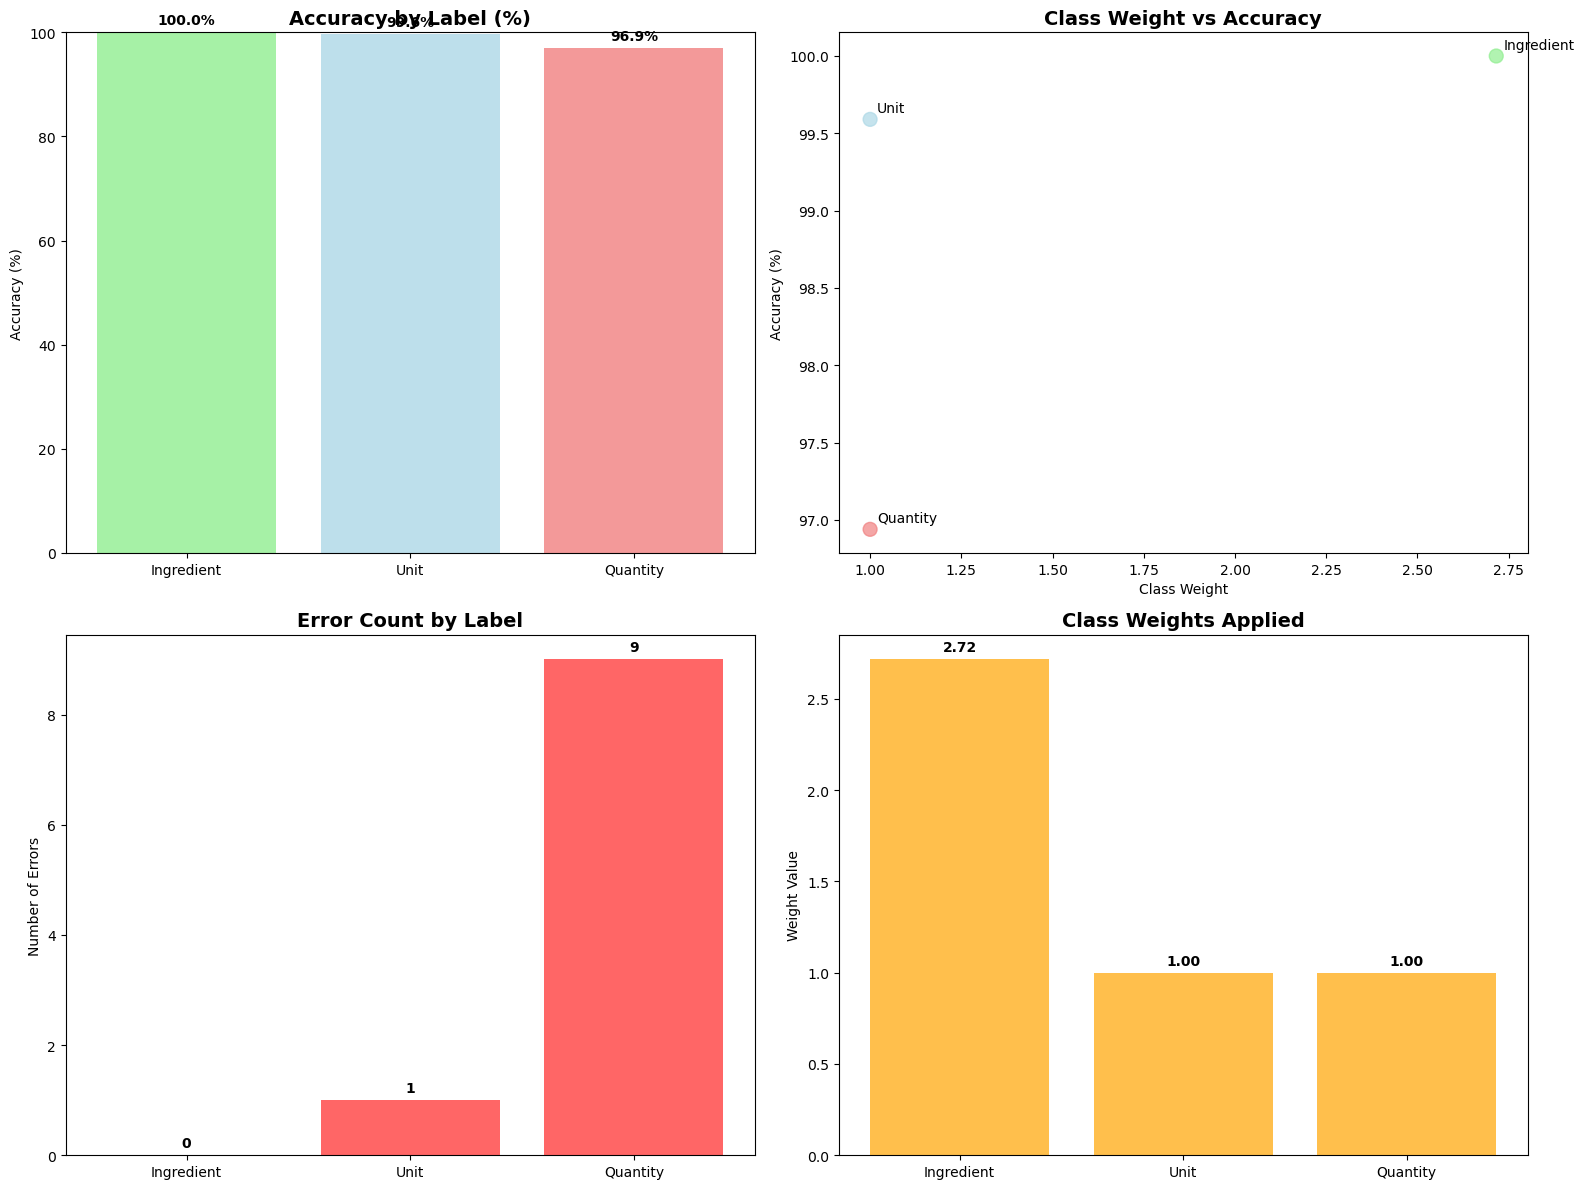


FINAL SUMMARY:
Total validation errors analyzed: 0
Labels with highest errors: Quantity
Labels with lowest accuracy: Quantity
Class weight effectiveness: Ingredient penalty applied


In [471]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_label_performance(label_analysis, weight_dict):
    """
    Create visualizations for label-wise performance analysis
    """
    
    print(f"\n📈 CREATING LABEL PERFORMANCE VISUALIZATIONS")
    print("=" * 50)
    
    if label_analysis.empty:
        print("No data to visualize")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Accuracy by Label
    labels = label_analysis['Label']
    accuracies = label_analysis['Accuracy'] * 100
    colors = ['lightgreen', 'lightblue', 'lightcoral']
    
    bars1 = axes[0,0].bar(labels, accuracies, color=colors, alpha=0.8)
    axes[0,0].set_title('Accuracy by Label (%)', fontweight='bold', fontsize=14)
    axes[0,0].set_ylabel('Accuracy (%)')
    axes[0,0].set_ylim(0, 100)
    
    # Add value labels
    for bar, acc in zip(bars1, accuracies):
        height = bar.get_height()
        axes[0,0].text(bar.get_x() + bar.get_width()/2., height + 1,
                       f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    # 2. Class Weights vs Accuracy
    weights = label_analysis['Class_Weight']
    
    axes[0,1].scatter(weights, accuracies, s=100, c=colors, alpha=0.7)
    axes[0,1].set_title('Class Weight vs Accuracy', fontweight='bold', fontsize=14)
    axes[0,1].set_xlabel('Class Weight')
    axes[0,1].set_ylabel('Accuracy (%)')
    
    # Add labels to points
    for i, label in enumerate(labels):
        axes[0,1].annotate(label, (weights.iloc[i], accuracies.iloc[i]), 
                          xytext=(5, 5), textcoords='offset points')
    
    # 3. Error Distribution
    errors = label_analysis['Errors']
    
    bars3 = axes[1,0].bar(labels, errors, color='red', alpha=0.6)
    axes[1,0].set_title('Error Count by Label', fontweight='bold', fontsize=14)
    axes[1,0].set_ylabel('Number of Errors')
    
    # Add value labels
    for bar, err in zip(bars3, errors):
        height = bar.get_height()
        axes[1,0].text(bar.get_x() + bar.get_width()/2., height + max(errors) * 0.01,
                       str(err), ha='center', va='bottom', fontweight='bold')
    
    # 4. Class Weight Impact
    weight_impact = label_analysis['Class_Weight']
    
    bars4 = axes[1,1].bar(labels, weight_impact, color='orange', alpha=0.7)
    axes[1,1].set_title('Class Weights Applied', fontweight='bold', fontsize=14)
    axes[1,1].set_ylabel('Weight Value')
    
    # Add value labels
    for bar, weight in zip(bars4, weight_impact):
        height = bar.get_height()
        axes[1,1].text(bar.get_x() + bar.get_width()/2., height + max(weight_impact) * 0.01,
                       f'{weight:.2f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Create visualizations
visualize_label_performance(label_analysis, weight_dict)

# Summary statistics
print(f"\nFINAL SUMMARY:")
print("=" * 30)
print(f"Total validation errors analyzed: {len(df_detailed_errors)}")
print(f"Labels with highest errors: {label_analysis.nlargest(1, 'Errors')['Label'].iloc[0] if not label_analysis.empty else 'None'}")
print(f"Labels with lowest accuracy: {label_analysis.nsmallest(1, 'Accuracy')['Label'].iloc[0] if not label_analysis.empty else 'None'}")
print(f"Class weight effectiveness: {'Ingredient penalty applied' if weight_dict.get('ingredient', 1) > 1 else 'No penalties applied'}")

 <font color = red>[Write your answer]</font>

## **10** Conclusion (Optional) <font color = red>[0 marks]</font> <br>

Write your findings and conclusion.